# Comparing Plate Metrics

In this notebook we evaluate the effect of different types of layouts when calculating quality assessment metrics as in [1].

We begin by importing required packages.

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np

# Our libraries
import libraries.disturbances as dt
import libraries.utilities as util
import libraries.screening as sc

## Data Generation

Here you can specify the details of the experiment.

We generated data based on [1], using layouts with 10 positive and 10 negative controls. 


In [4]:
## Simulation parameters
## PLAID article only uses (10,10). We generate all 3 for posterity here
neg_pos_controls_list = [(8,8),(10,10),(20,10)]

id_text = "reviewing" #Used to personalise the output filenames.

max_error = 26 # Upper limit of the error levels that will be tested. 
               #The number is not included. 20 is already quite strong, depending on other values
               # such as the mean and stdev of the controls, plate size, etc

neg_control_mean=100 #Keep at 100 to simplify calculations relative to percentage of negative control.
pos_control_mean=5
neg_stdev=3
pos_stdev=4

# Types of plate errors
# More plate errors can be added to this list. Other examples at the end of this notebook
error_types = [{'type':"bowl-nl", 'error_function':dt.add_bowlshaped_errors_nl}]


# Other layouts will be selected from the plate randomly filled with 50% positive and 50% negative controls
data_directory = 'generated-data/quality-assessment-metrics/'
plots_directory = 'generated-plots/quality-assessment-metrics/'

Now we test all the metrics by calculating both the Z' factor and the SSMD on plates containing 50% negative controls and 50% positive controls, then sampling 10 positive controls and 10 negative controls according to COMPD, PLAID (effective), random, and border layouts.

In [6]:
output_file_list = []
for (neg_controls, pos_controls) in neg_pos_controls_list:
    print("\nPlate ", neg_controls, "-", pos_controls, ":")
    plate_types = [#{'type':'Border','dir':'layouts/screening_BORDR_layouts/','regex':'plate_layout_border_'+str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy'},
                    {'type':'random','dir':'layouts/screening_RANDM_layouts/','regex':'plate_layout_rand_'  +str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy'},
                    {'type':'plaid', 'dir':'layouts/screening_PLAID_layouts/','regex':'plate_layout_'       +str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy'},
                    {'type':'compd', 'dir':'layouts/screening_COMPD_layouts/','regex':'plate_layout_'       +str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy'}]
    
    for i in range(0,max_error):
        error = i/100
        screening_scores_data_filename = sc.test_quality_assessment_metrics(plate_types,error_types,error,id_text,neg_controls,pos_controls,neg_control_mean,pos_control_mean,neg_stdev,pos_stdev,data_directory)
        output_file_list.append(screening_scores_data_filename)

        print("\nThe generated data for " +str(i/100).zfill(3) + " was stored in: "+screening_scores_data_filename)


Plate  8 - 8 :

The generated data for 0.0 was stored in: screening_metrics_data-8-8-0.0-20250623-reviewing.csv

The generated data for 0.01 was stored in: screening_metrics_data-8-8-0.01-20250623-reviewing.csv

The generated data for 0.02 was stored in: screening_metrics_data-8-8-0.02-20250623-reviewing.csv

The generated data for 0.03 was stored in: screening_metrics_data-8-8-0.03-20250623-reviewing.csv

The generated data for 0.04 was stored in: screening_metrics_data-8-8-0.04-20250623-reviewing.csv

The generated data for 0.05 was stored in: screening_metrics_data-8-8-0.05-20250623-reviewing.csv

The generated data for 0.06 was stored in: screening_metrics_data-8-8-0.06-20250623-reviewing.csv

The generated data for 0.07 was stored in: screening_metrics_data-8-8-0.07-20250623-reviewing.csv

The generated data for 0.08 was stored in: screening_metrics_data-8-8-0.08-20250623-reviewing.csv

The generated data for 0.09 was stored in: screening_metrics_data-8-8-0.09-20250623-reviewing.

## Plotting the data

Now we can plot the data that was just generated. First we look at the Z' factor.

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.488e-01 t=-7.587e-01
plaid vs. compd: t-test independent samples, P_val:6.080e-01 t=-5.136e-01
random vs. compd: t-test independent samples, P_val:2.109e-01 t=-1.255e+00


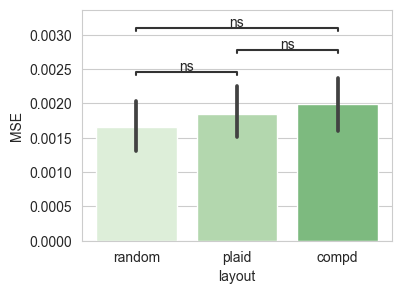

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.486e-01 t=1.911e-01
plaid vs. compd: t-test independent samples, P_val:4.683e-01 t=7.265e-01
random vs. compd: t-test independent samples, P_val:3.226e-01 t=9.912e-01


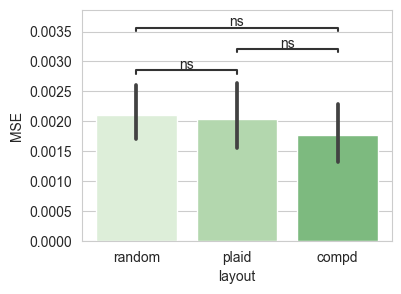

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.176e-03 t=2.822e+00
plaid vs. compd: t-test independent samples, P_val:1.373e-01 t=1.491e+00
random vs. compd: t-test independent samples, P_val:3.087e-05 t=4.249e+00


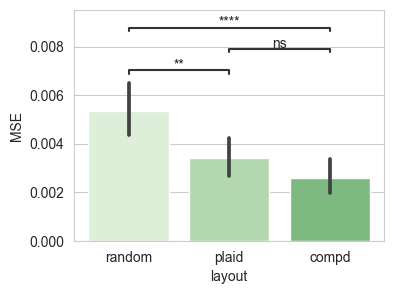

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.926e-02 t=2.357e+00
plaid vs. compd: t-test independent samples, P_val:9.069e-01 t=-1.170e-01
random vs. compd: t-test independent samples, P_val:3.214e-02 t=2.155e+00


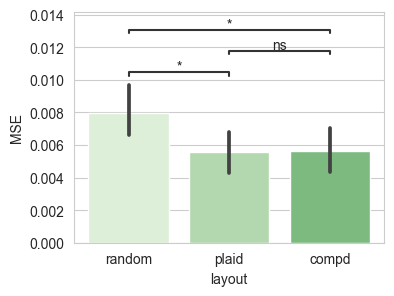

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.497e-02 t=2.121e+00
plaid vs. compd: t-test independent samples, P_val:1.173e-01 t=1.572e+00
random vs. compd: t-test independent samples, P_val:1.400e-04 t=3.871e+00


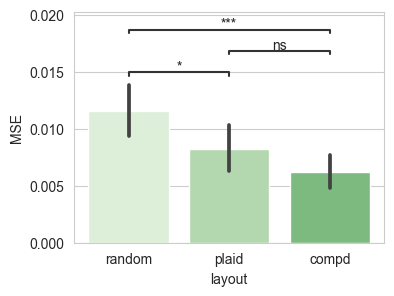

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.734e-04 t=3.340e+00
plaid vs. compd: t-test independent samples, P_val:8.025e-01 t=2.504e-01
random vs. compd: t-test independent samples, P_val:7.374e-04 t=3.420e+00


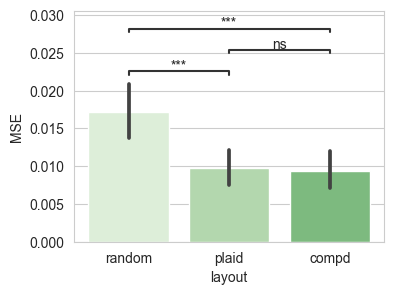

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.724e-05 t=4.387e+00
plaid vs. compd: t-test independent samples, P_val:8.010e-01 t=-2.524e-01
random vs. compd: t-test independent samples, P_val:3.296e-04 t=3.644e+00


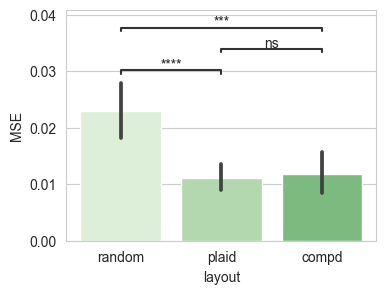

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.468e-03 t=2.952e+00
plaid vs. compd: t-test independent samples, P_val:3.383e-01 t=9.595e-01
random vs. compd: t-test independent samples, P_val:1.876e-04 t=3.795e+00


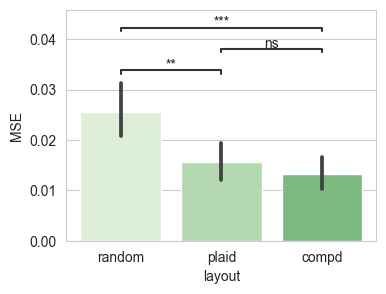

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.024e-04 t=3.952e+00
plaid vs. compd: t-test independent samples, P_val:9.542e-01 t=5.744e-02
random vs. compd: t-test independent samples, P_val:1.217e-04 t=3.907e+00


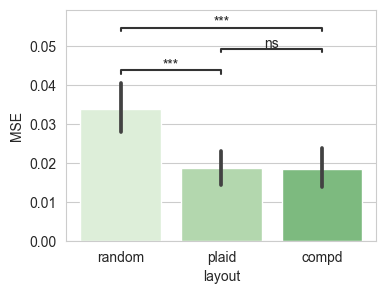

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.765e-03 t=2.849e+00
plaid vs. compd: t-test independent samples, P_val:2.639e-01 t=1.120e+00
random vs. compd: t-test independent samples, P_val:1.372e-04 t=3.876e+00


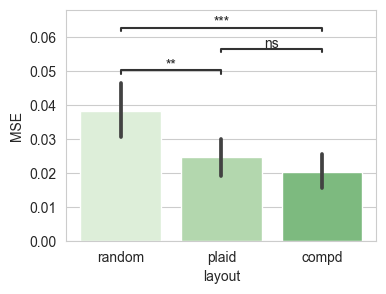

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.683e-03 t=2.933e+00
plaid vs. compd: t-test independent samples, P_val:1.023e-01 t=1.640e+00
random vs. compd: t-test independent samples, P_val:8.030e-06 t=4.564e+00


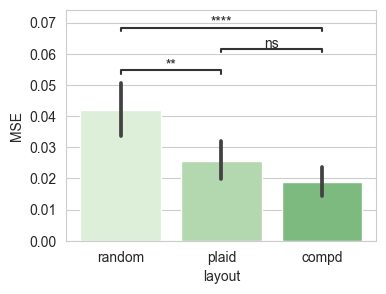

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.875e-03 t=3.145e+00
plaid vs. compd: t-test independent samples, P_val:1.165e-01 t=1.575e+00
random vs. compd: t-test independent samples, P_val:5.696e-06 t=4.642e+00


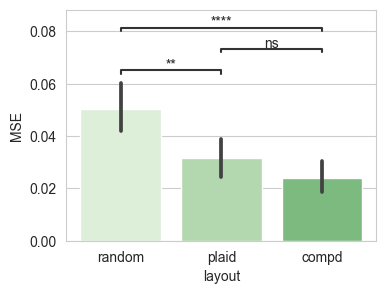

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.046e-04 t=3.433e+00
plaid vs. compd: t-test independent samples, P_val:5.115e-02 t=1.960e+00
random vs. compd: t-test independent samples, P_val:6.881e-07 t=5.102e+00


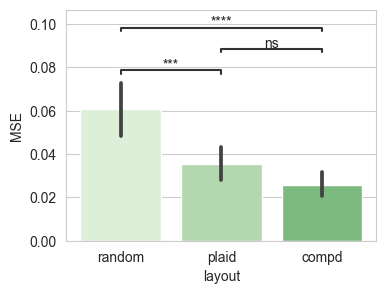

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.443e-04 t=3.417e+00
plaid vs. compd: t-test independent samples, P_val:1.731e-01 t=1.367e+00
random vs. compd: t-test independent samples, P_val:1.466e-05 t=4.425e+00


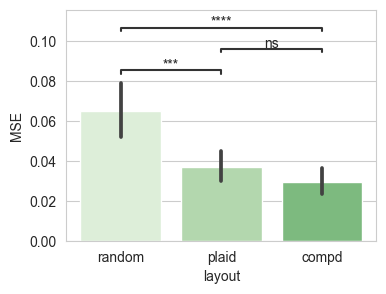

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.238e-03 t=3.269e+00
plaid vs. compd: t-test independent samples, P_val:7.197e-01 t=3.592e-01
random vs. compd: t-test independent samples, P_val:3.433e-04 t=3.633e+00


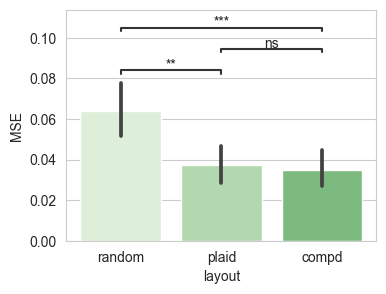

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.853e-03 t=2.639e+00
plaid vs. compd: t-test independent samples, P_val:1.134e-01 t=1.589e+00
random vs. compd: t-test independent samples, P_val:1.616e-05 t=4.403e+00


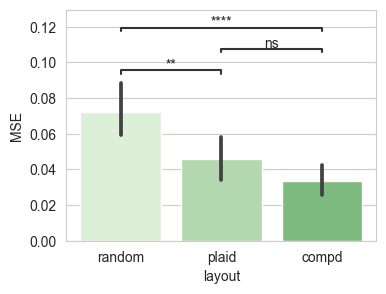

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.300e-04 t=3.423e+00
plaid vs. compd: t-test independent samples, P_val:4.436e-01 t=7.674e-01
random vs. compd: t-test independent samples, P_val:6.622e-05 t=4.061e+00


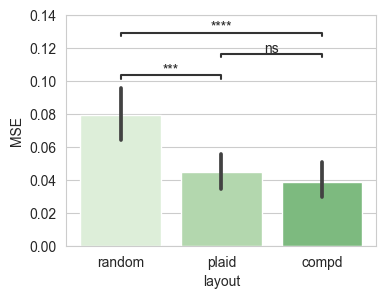

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.565e-03 t=3.199e+00
plaid vs. compd: t-test independent samples, P_val:4.861e-02 t=1.982e+00
random vs. compd: t-test independent samples, P_val:5.177e-06 t=4.664e+00


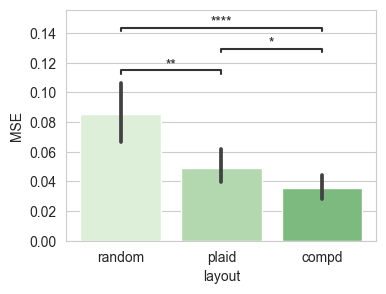

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.620e-03 t=3.189e+00
plaid vs. compd: t-test independent samples, P_val:8.313e-02 t=1.740e+00
random vs. compd: t-test independent samples, P_val:2.161e-05 t=4.334e+00


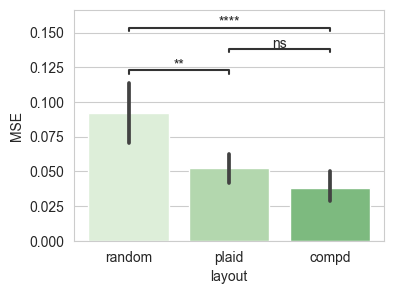

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.314e-03 t=2.967e+00
plaid vs. compd: t-test independent samples, P_val:2.915e-01 t=1.057e+00
random vs. compd: t-test independent samples, P_val:2.598e-04 t=3.708e+00


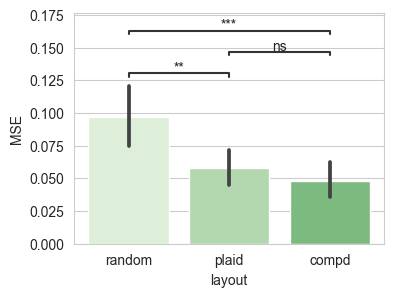

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.685e-04 t=3.493e+00
plaid vs. compd: t-test independent samples, P_val:2.093e-01 t=1.259e+00
random vs. compd: t-test independent samples, P_val:1.437e-05 t=4.430e+00


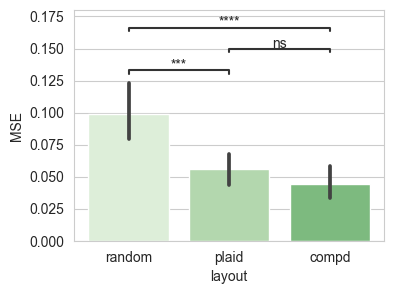

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.156e-03 t=3.102e+00
plaid vs. compd: t-test independent samples, P_val:4.003e-02 t=2.065e+00
random vs. compd: t-test independent samples, P_val:5.090e-06 t=4.668e+00


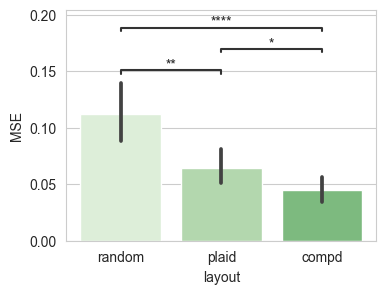

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.839e-03 t=2.682e+00
plaid vs. compd: t-test independent samples, P_val:1.075e-01 t=1.616e+00
random vs. compd: t-test independent samples, P_val:1.233e-04 t=3.904e+00


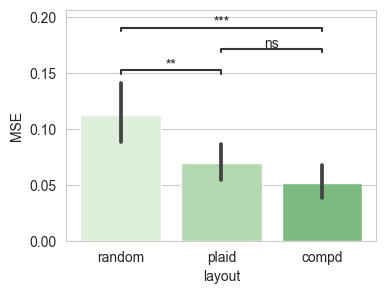

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.312e-02 t=2.499e+00
plaid vs. compd: t-test independent samples, P_val:2.887e-02 t=2.199e+00
random vs. compd: t-test independent samples, P_val:4.011e-05 t=4.185e+00


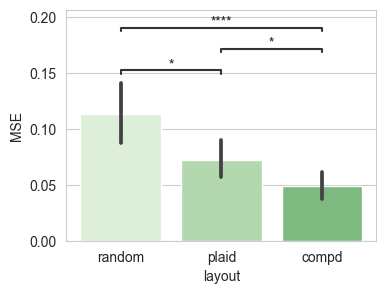

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.230e-03 t=2.819e+00
plaid vs. compd: t-test independent samples, P_val:1.264e-02 t=2.513e+00
random vs. compd: t-test independent samples, P_val:9.667e-06 t=4.522e+00


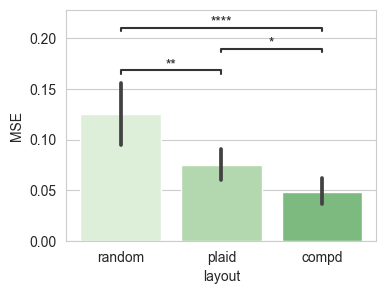

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.091e-03 t=3.306e+00
plaid vs. compd: t-test independent samples, P_val:5.073e-01 t=6.640e-01
random vs. compd: t-test independent samples, P_val:2.500e-04 t=3.718e+00


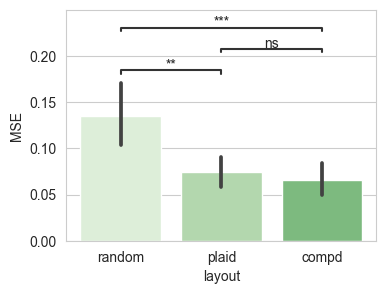

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.567e-01 t=-5.886e-01
plaid vs. compd: t-test independent samples, P_val:7.068e-01 t=-3.767e-01
random vs. compd: t-test independent samples, P_val:3.909e-01 t=-8.595e-01


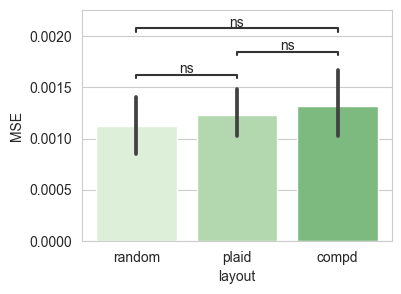

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.363e-01 t=3.371e-01
plaid vs. compd: t-test independent samples, P_val:8.304e-01 t=2.144e-01
random vs. compd: t-test independent samples, P_val:5.517e-01 t=5.961e-01


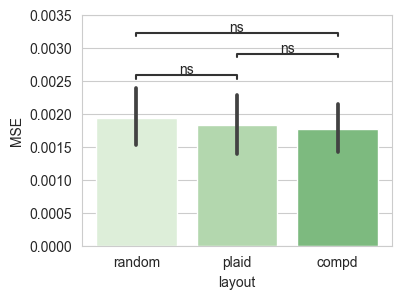

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.378e-01 t=7.772e-01
plaid vs. compd: t-test independent samples, P_val:8.249e-01 t=2.214e-01
random vs. compd: t-test independent samples, P_val:3.443e-01 t=9.477e-01


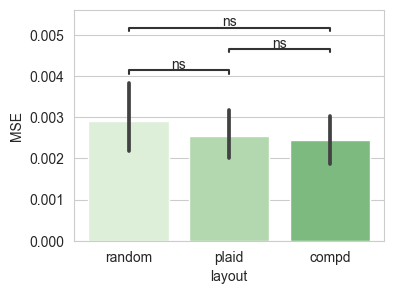

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.221e-01 t=1.552e+00
plaid vs. compd: t-test independent samples, P_val:2.014e-03 t=3.123e+00
random vs. compd: t-test independent samples, P_val:3.872e-04 t=3.600e+00


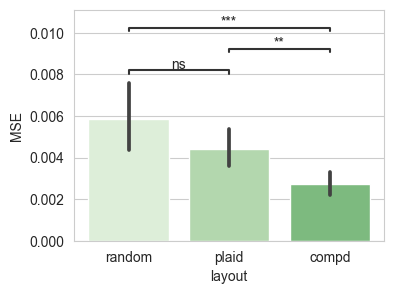

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.151e-02 t=2.050e+00
plaid vs. compd: t-test independent samples, P_val:4.070e-02 t=2.058e+00
random vs. compd: t-test independent samples, P_val:1.345e-04 t=3.881e+00


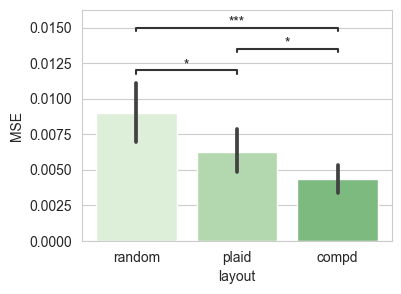

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.432e-03 t=3.065e+00
plaid vs. compd: t-test independent samples, P_val:1.140e-01 t=1.586e+00
random vs. compd: t-test independent samples, P_val:3.495e-05 t=4.219e+00


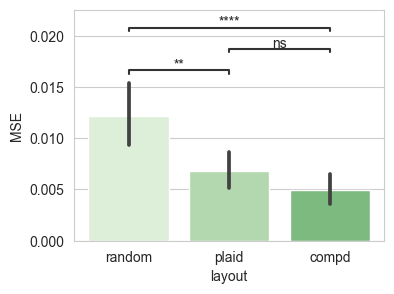

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.291e-01 t=1.523e+00
plaid vs. compd: t-test independent samples, P_val:3.552e-03 t=2.945e+00
random vs. compd: t-test independent samples, P_val:9.787e-05 t=3.963e+00


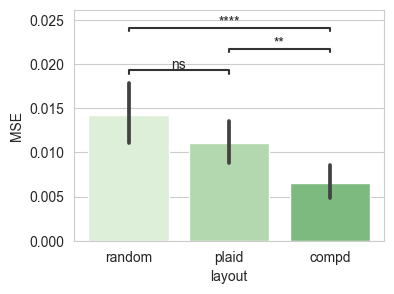

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.128e-01 t=1.592e+00
plaid vs. compd: t-test independent samples, P_val:6.095e-02 t=1.883e+00
random vs. compd: t-test independent samples, P_val:8.161e-04 t=3.391e+00


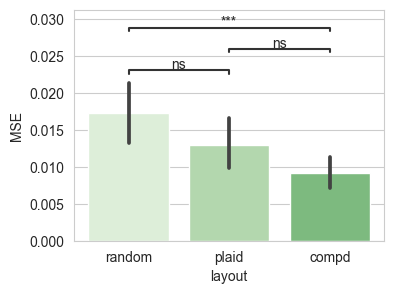

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.607e-02 t=2.239e+00
plaid vs. compd: t-test independent samples, P_val:3.009e-03 t=2.998e+00
random vs. compd: t-test independent samples, P_val:1.109e-05 t=4.490e+00


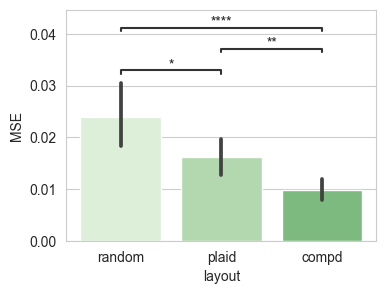

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.725e-03 t=3.029e+00
plaid vs. compd: t-test independent samples, P_val:8.572e-02 t=1.726e+00
random vs. compd: t-test independent samples, P_val:3.196e-05 t=4.240e+00


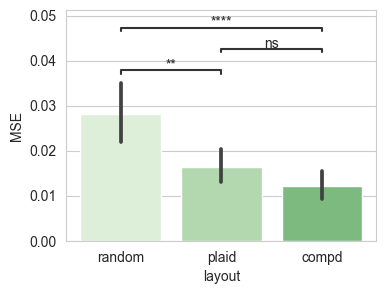

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.416e-03 t=2.750e+00
plaid vs. compd: t-test independent samples, P_val:1.212e-01 t=1.555e+00
random vs. compd: t-test independent samples, P_val:7.870e-05 t=4.018e+00


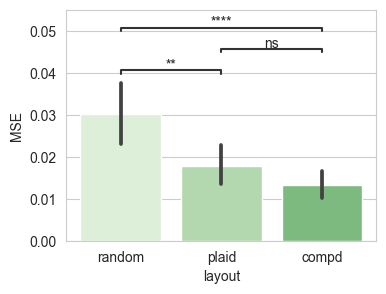

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.059e-02 t=2.331e+00
plaid vs. compd: t-test independent samples, P_val:6.364e-02 t=1.863e+00
random vs. compd: t-test independent samples, P_val:4.981e-04 t=3.530e+00


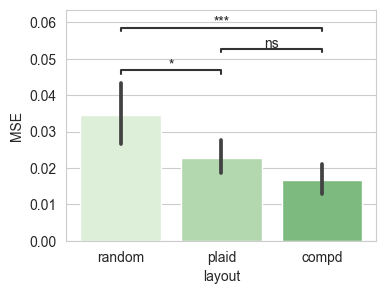

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.033e-03 t=2.995e+00
plaid vs. compd: t-test independent samples, P_val:2.978e-01 t=1.043e+00
random vs. compd: t-test independent samples, P_val:3.657e-04 t=3.616e+00


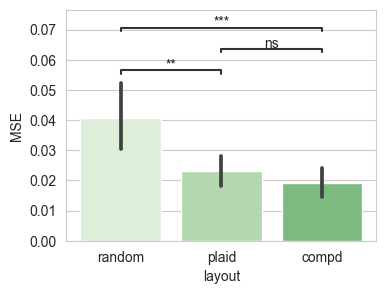

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.503e-03 t=3.055e+00
plaid vs. compd: t-test independent samples, P_val:8.924e-03 t=2.637e+00
random vs. compd: t-test independent samples, P_val:8.509e-07 t=5.057e+00


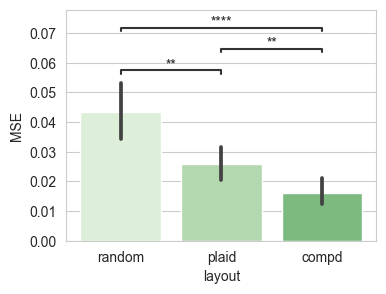

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.297e-02 t=2.289e+00
plaid vs. compd: t-test independent samples, P_val:2.577e-01 t=1.135e+00
random vs. compd: t-test independent samples, P_val:9.772e-04 t=3.339e+00


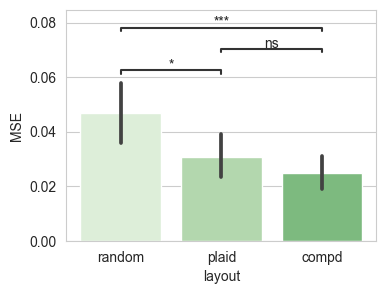

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.530e-03 t=2.947e+00
plaid vs. compd: t-test independent samples, P_val:4.582e-02 t=2.008e+00
random vs. compd: t-test independent samples, P_val:2.249e-05 t=4.325e+00


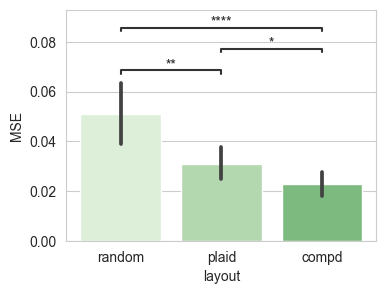

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.122e-03 t=3.107e+00
plaid vs. compd: t-test independent samples, P_val:2.999e-02 t=2.183e+00
random vs. compd: t-test independent samples, P_val:1.693e-06 t=4.910e+00


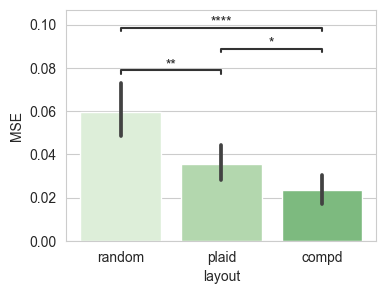

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.356e-02 t=2.279e+00
plaid vs. compd: t-test independent samples, P_val:4.764e-02 t=1.991e+00
random vs. compd: t-test independent samples, P_val:9.622e-05 t=3.967e+00


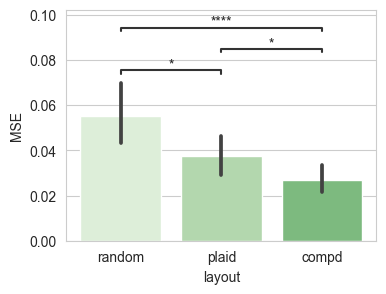

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.187e-02 t=2.046e+00
plaid vs. compd: t-test independent samples, P_val:3.715e-02 t=2.096e+00
random vs. compd: t-test independent samples, P_val:7.661e-05 t=4.025e+00


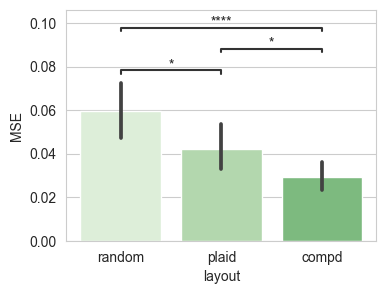

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.727e-02 t=2.398e+00
plaid vs. compd: t-test independent samples, P_val:8.678e-02 t=1.720e+00
random vs. compd: t-test independent samples, P_val:2.143e-04 t=3.760e+00


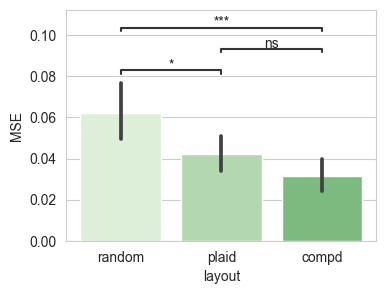

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.325e-04 t=3.385e+00
plaid vs. compd: t-test independent samples, P_val:3.747e-02 t=2.092e+00
random vs. compd: t-test independent samples, P_val:2.739e-06 t=4.805e+00


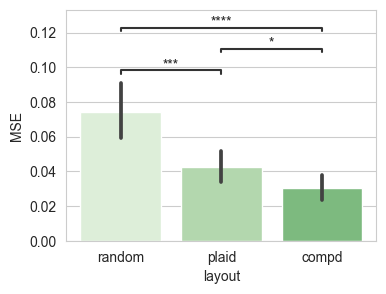

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.483e-03 t=2.654e+00
plaid vs. compd: t-test independent samples, P_val:1.486e-02 t=2.454e+00
random vs. compd: t-test independent samples, P_val:2.986e-05 t=4.257e+00


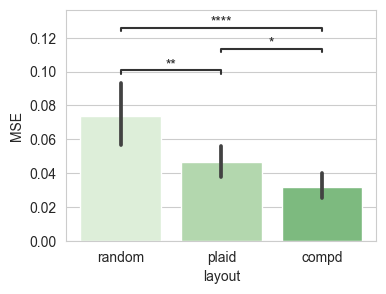

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.158e-02 t=2.313e+00
plaid vs. compd: t-test independent samples, P_val:2.605e-02 t=2.240e+00
random vs. compd: t-test independent samples, P_val:3.041e-05 t=4.252e+00


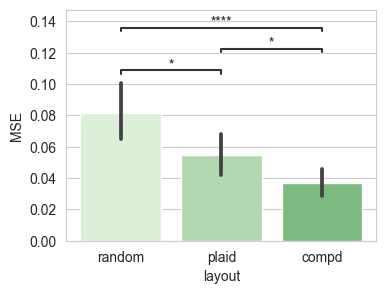

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.443e-02 t=2.265e+00
plaid vs. compd: t-test independent samples, P_val:1.462e-01 t=1.458e+00
random vs. compd: t-test independent samples, P_val:3.868e-04 t=3.600e+00


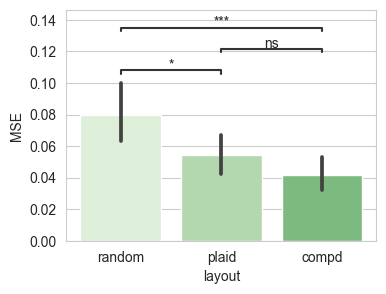

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.452e-04 t=3.417e+00
plaid vs. compd: t-test independent samples, P_val:9.758e-02 t=1.663e+00
random vs. compd: t-test independent samples, P_val:6.073e-06 t=4.628e+00


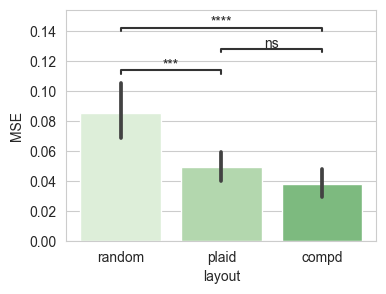

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.688e-03 t=2.933e+00
plaid vs. compd: t-test independent samples, P_val:4.380e-01 t=7.770e-01
random vs. compd: t-test independent samples, P_val:5.380e-04 t=3.509e+00


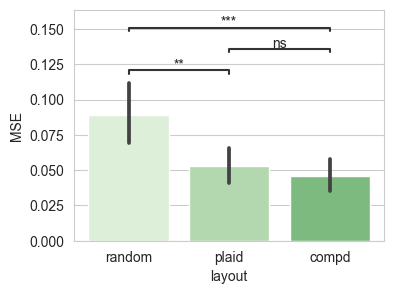

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.036e-02 t=-1.887e+00
plaid vs. compd: t-test independent samples, P_val:5.423e-02 t=1.935e+00
random vs. compd: t-test independent samples, P_val:9.742e-01 t=-3.232e-02


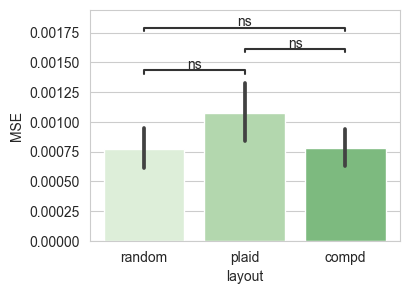

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.493e-01 t=1.447e+00
plaid vs. compd: t-test independent samples, P_val:6.897e-01 t=3.998e-01
random vs. compd: t-test independent samples, P_val:5.098e-02 t=1.962e+00


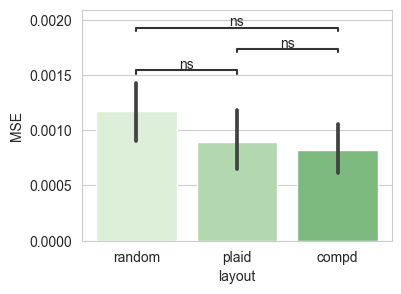

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.211e-02 t=1.746e+00
plaid vs. compd: t-test independent samples, P_val:1.221e-01 t=-1.552e+00
random vs. compd: t-test independent samples, P_val:7.904e-01 t=2.660e-01


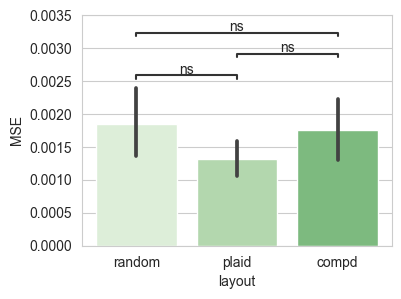

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.725e-04 t=3.695e+00
plaid vs. compd: t-test independent samples, P_val:1.465e-01 t=-1.457e+00
random vs. compd: t-test independent samples, P_val:1.130e-02 t=2.553e+00


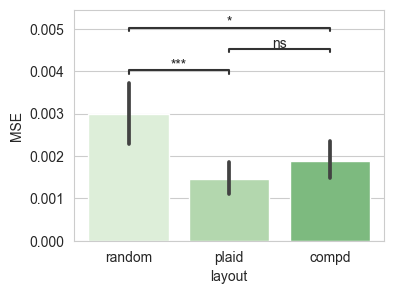

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.166e-03 t=2.668e+00
plaid vs. compd: t-test independent samples, P_val:3.861e-02 t=-2.080e+00
random vs. compd: t-test independent samples, P_val:2.015e-01 t=1.281e+00


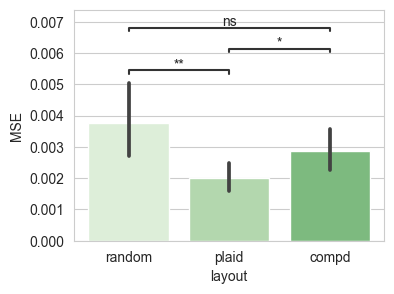

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.024e-04 t=3.528e+00
plaid vs. compd: t-test independent samples, P_val:1.377e-01 t=-1.489e+00
random vs. compd: t-test independent samples, P_val:7.544e-03 t=2.695e+00


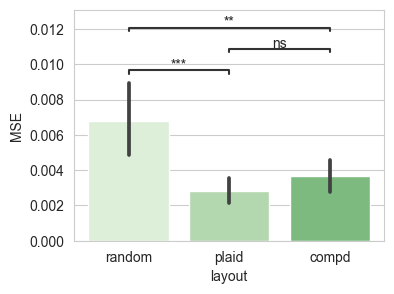

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.836e-05 t=4.373e+00
plaid vs. compd: t-test independent samples, P_val:6.357e-02 t=-1.864e+00
random vs. compd: t-test independent samples, P_val:7.654e-04 t=3.409e+00


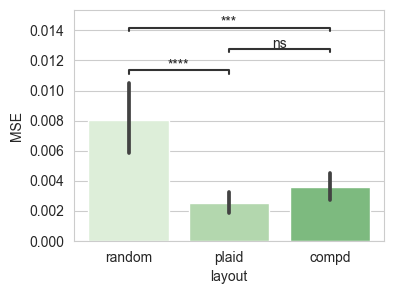

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.842e-04 t=3.337e+00
plaid vs. compd: t-test independent samples, P_val:1.445e-01 t=-1.464e+00
random vs. compd: t-test independent samples, P_val:7.751e-03 t=2.686e+00


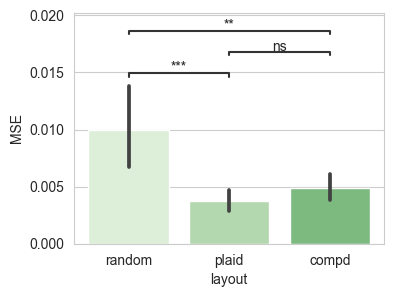

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.787e-05 t=4.379e+00
plaid vs. compd: t-test independent samples, P_val:4.331e-04 t=-3.569e+00
random vs. compd: t-test independent samples, P_val:4.972e-03 t=2.835e+00


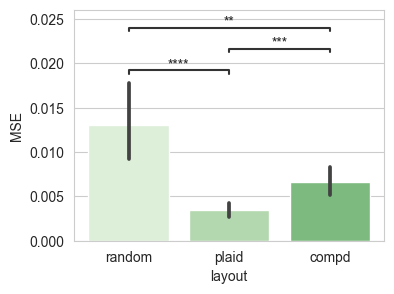

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.793e-04 t=3.689e+00
plaid vs. compd: t-test independent samples, P_val:3.914e-03 t=-2.913e+00
random vs. compd: t-test independent samples, P_val:2.115e-02 t=2.321e+00


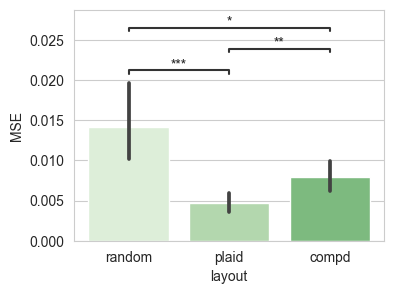

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.924e-05 t=4.089e+00
plaid vs. compd: t-test independent samples, P_val:2.151e-03 t=-3.102e+00
random vs. compd: t-test independent samples, P_val:7.154e-03 t=2.713e+00


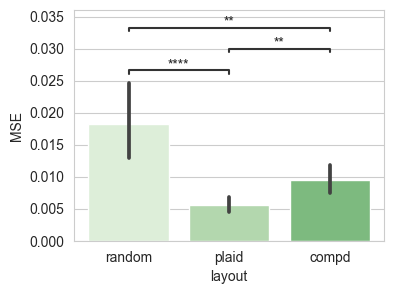

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.380e-04 t=3.875e+00
plaid vs. compd: t-test independent samples, P_val:1.005e-03 t=-3.331e+00
random vs. compd: t-test independent samples, P_val:1.869e-02 t=2.368e+00


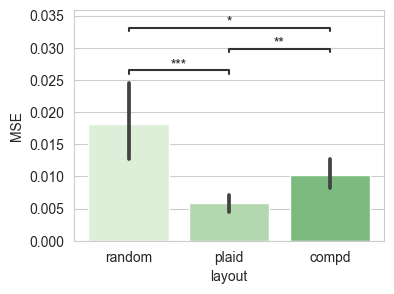

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.201e-04 t=3.752e+00
plaid vs. compd: t-test independent samples, P_val:3.055e-01 t=-1.027e+00
random vs. compd: t-test independent samples, P_val:1.043e-03 t=3.320e+00


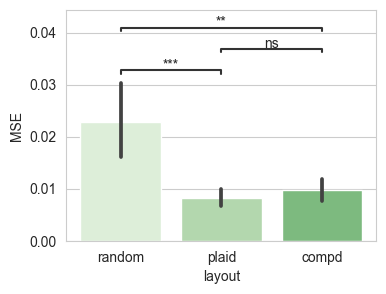

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.185e-05 t=4.331e+00
plaid vs. compd: t-test independent samples, P_val:2.534e-03 t=-3.052e+00
random vs. compd: t-test independent samples, P_val:3.297e-03 t=2.969e+00


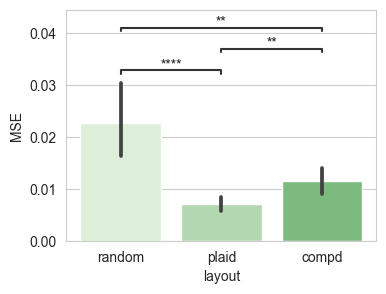

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.043e-04 t=3.666e+00
plaid vs. compd: t-test independent samples, P_val:3.101e-02 t=-2.170e+00
random vs. compd: t-test independent samples, P_val:6.475e-03 t=2.747e+00


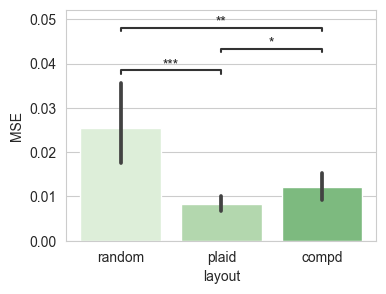

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.036e-04 t=3.948e+00
plaid vs. compd: t-test independent samples, P_val:2.345e-01 t=-1.192e+00
random vs. compd: t-test independent samples, P_val:8.311e-04 t=3.385e+00


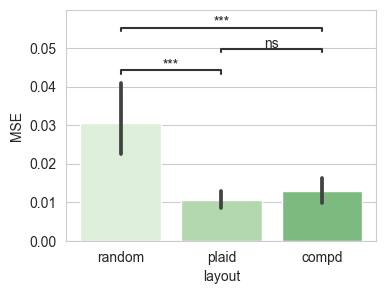

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.171e-05 t=4.478e+00
plaid vs. compd: t-test independent samples, P_val:1.982e-04 t=-3.780e+00
random vs. compd: t-test independent samples, P_val:3.075e-03 t=2.991e+00


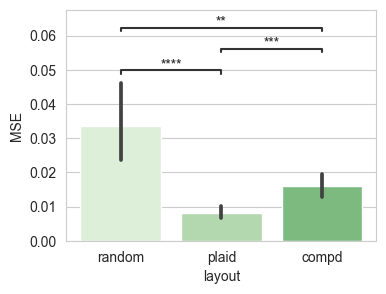

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.137e-04 t=3.925e+00
plaid vs. compd: t-test independent samples, P_val:9.492e-02 t=-1.677e+00
random vs. compd: t-test independent samples, P_val:1.390e-03 t=3.235e+00


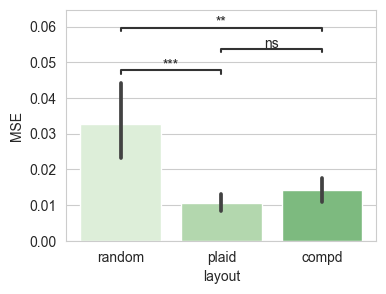

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.885e-05 t=4.265e+00
plaid vs. compd: t-test independent samples, P_val:1.488e-01 t=-1.448e+00
random vs. compd: t-test independent samples, P_val:2.240e-04 t=3.748e+00


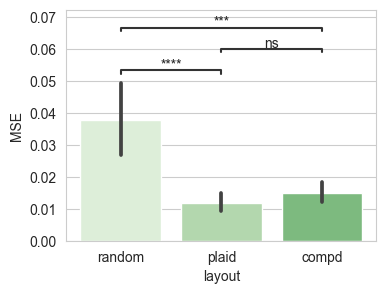

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.739e-05 t=4.385e+00
plaid vs. compd: t-test independent samples, P_val:3.871e-03 t=-2.917e+00
random vs. compd: t-test independent samples, P_val:8.205e-04 t=3.389e+00


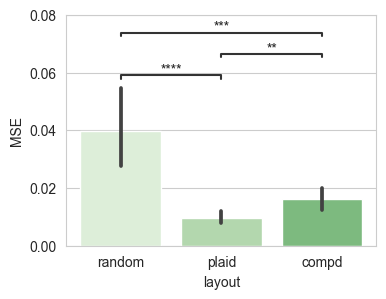

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.855e-04 t=3.683e+00
plaid vs. compd: t-test independent samples, P_val:8.957e-02 t=-1.705e+00
random vs. compd: t-test independent samples, P_val:3.574e-03 t=2.943e+00


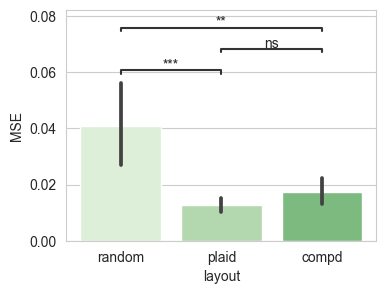

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.011e-04 t=3.955e+00
plaid vs. compd: t-test independent samples, P_val:1.193e-01 t=-1.563e+00
random vs. compd: t-test independent samples, P_val:1.011e-03 t=3.329e+00


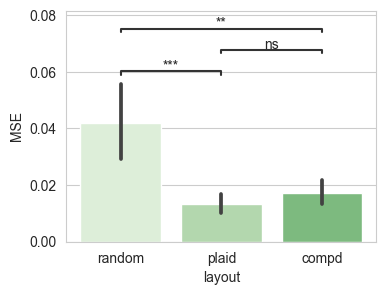

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.300e-05 t=4.117e+00
plaid vs. compd: t-test independent samples, P_val:2.468e-03 t=-3.060e+00
random vs. compd: t-test independent samples, P_val:3.405e-03 t=2.958e+00


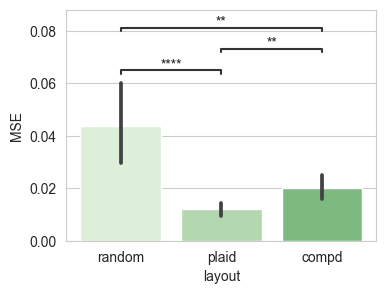

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.694e-04 t=3.822e+00
plaid vs. compd: t-test independent samples, P_val:9.795e-01 t=-2.573e-02
random vs. compd: t-test independent samples, P_val:2.028e-04 t=3.774e+00


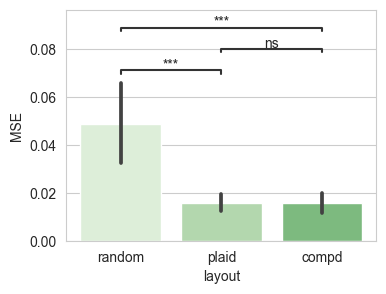

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.265e-05 t=4.118e+00
plaid vs. compd: t-test independent samples, P_val:2.342e-02 t=-2.281e+00
random vs. compd: t-test independent samples, P_val:9.552e-04 t=3.345e+00


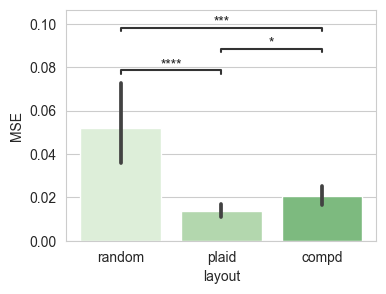

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.005e-04 t=3.777e+00
plaid vs. compd: t-test independent samples, P_val:2.354e-03 t=-3.075e+00
random vs. compd: t-test independent samples, P_val:7.717e-03 t=2.687e+00


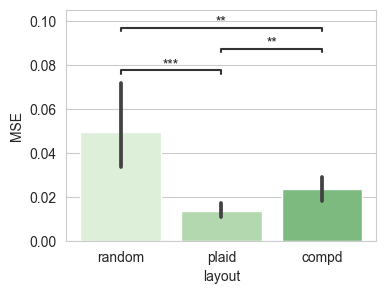

In [8]:
for screening_scores_data_filename in output_file_list:
    util.plotting_residual_metrics(data_directory+screening_scores_data_filename,metric='Zfactor',
                                   fig_name=screening_scores_data_filename, y_max = None, palette = None,
                                   plots_directory = plots_directory,
                                   box_pairs = [("random", "plaid"),
                                                ("random", "compd"),
                                                ("plaid", "compd")
                                               ],
                                   order = ["random","plaid","compd"]
#                                   box_pairs = [("border", "random"),
#                                                ("border", "plaid"),
#                                                ("border", "compd"),
#                                                ("random", "plaid"),
#                                                ("random", "compd"),
#                                                ("plaid", "compd")
#                                               ],
#                                   order = ["border","random","plaid","compd"]
                                  )


Now we look at the SSMD comparison 

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.640e-01 t=-4.349e-01
plaid vs. compd: t-test independent samples, P_val:5.360e-01 t=-6.198e-01
random vs. compd: t-test independent samples, P_val:2.641e-01 t=-1.119e+00


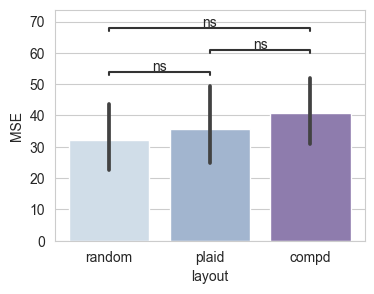

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.190e-01 t=2.291e-01
plaid vs. compd: t-test independent samples, P_val:2.113e-02 t=2.321e+00
random vs. compd: t-test independent samples, P_val:2.401e-03 t=3.068e+00


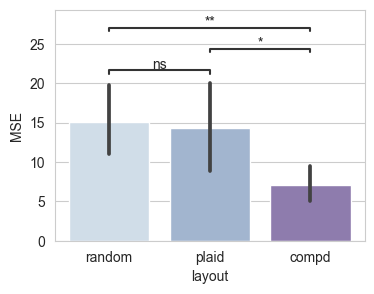

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.823e-03 t=3.153e+00
plaid vs. compd: t-test independent samples, P_val:1.469e-01 t=1.455e+00
random vs. compd: t-test independent samples, P_val:4.522e-05 t=4.156e+00


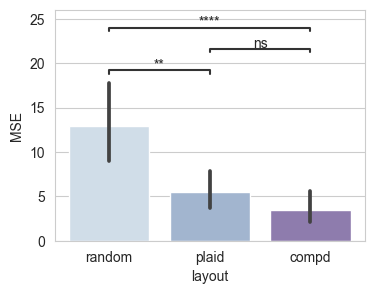

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.738e-02 t=2.220e+00
plaid vs. compd: t-test independent samples, P_val:7.756e-02 t=1.773e+00
random vs. compd: t-test independent samples, P_val:4.176e-05 t=4.175e+00


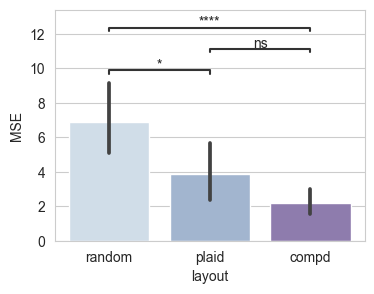

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.258e-02 t=2.295e+00
plaid vs. compd: t-test independent samples, P_val:4.285e-03 t=2.884e+00
random vs. compd: t-test independent samples, P_val:5.070e-07 t=5.165e+00


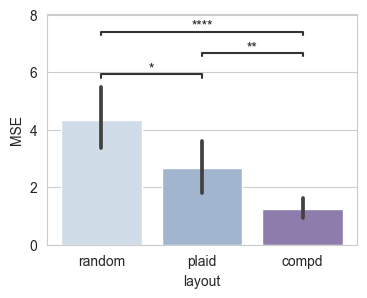

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.393e-03 t=2.959e+00
plaid vs. compd: t-test independent samples, P_val:2.054e-02 t=2.332e+00
random vs. compd: t-test independent samples, P_val:1.079e-05 t=4.497e+00


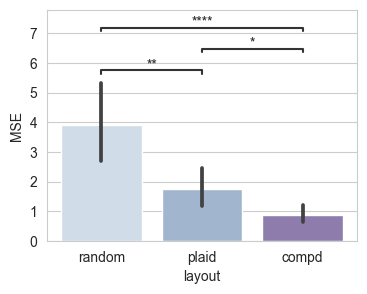

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.705e-04 t=3.820e+00
plaid vs. compd: t-test independent samples, P_val:5.370e-01 t=6.183e-01
random vs. compd: t-test independent samples, P_val:3.647e-04 t=3.616e+00


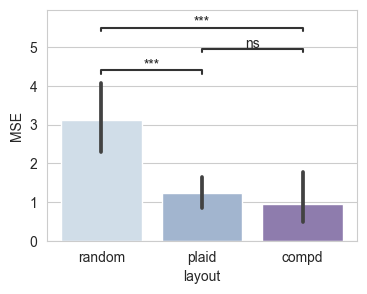

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.955e-02 t=2.070e+00
plaid vs. compd: t-test independent samples, P_val:1.416e-02 t=2.471e+00
random vs. compd: t-test independent samples, P_val:1.773e-04 t=3.809e+00


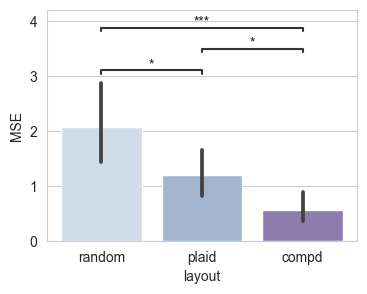

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.195e-03 t=2.626e+00
plaid vs. compd: t-test independent samples, P_val:2.150e-02 t=2.314e+00
random vs. compd: t-test independent samples, P_val:1.512e-06 t=4.934e+00


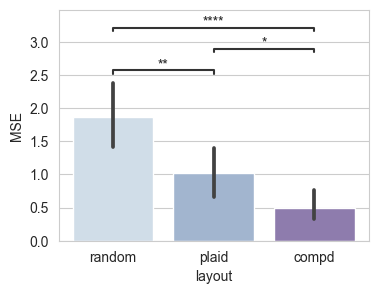

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.904e-02 t=2.196e+00
plaid vs. compd: t-test independent samples, P_val:2.937e-02 t=2.192e+00
random vs. compd: t-test independent samples, P_val:2.912e-05 t=4.263e+00


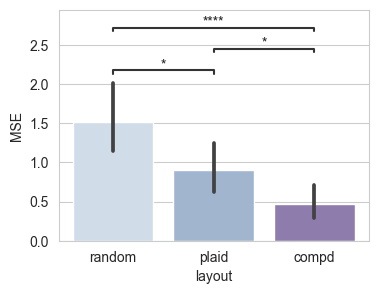

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.196e-02 t=2.158e+00
plaid vs. compd: t-test independent samples, P_val:9.428e-03 t=2.617e+00
random vs. compd: t-test independent samples, P_val:1.924e-06 t=4.882e+00


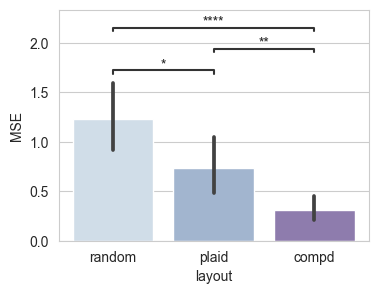

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.348e-02 t=2.139e+00
plaid vs. compd: t-test independent samples, P_val:2.949e-02 t=2.190e+00
random vs. compd: t-test independent samples, P_val:9.590e-06 t=4.524e+00


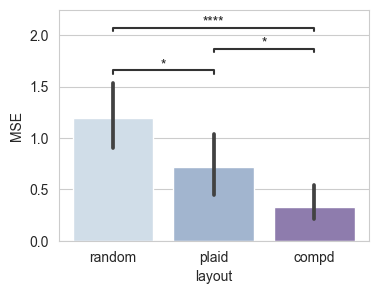

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.262e-03 t=2.624e+00
plaid vs. compd: t-test independent samples, P_val:6.302e-03 t=2.756e+00
random vs. compd: t-test independent samples, P_val:3.379e-08 t=5.708e+00


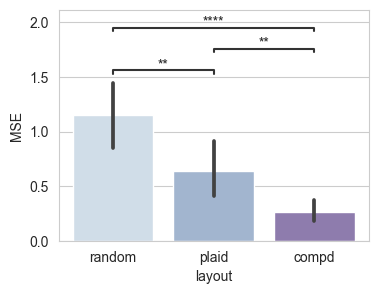

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.499e-02 t=2.450e+00
plaid vs. compd: t-test independent samples, P_val:2.150e-02 t=2.314e+00
random vs. compd: t-test independent samples, P_val:1.643e-05 t=4.399e+00


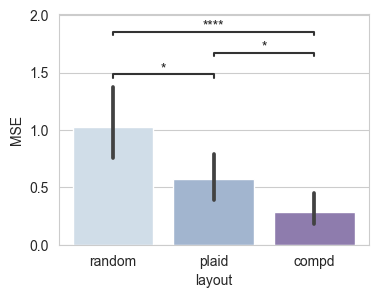

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.343e-03 t=2.754e+00
plaid vs. compd: t-test independent samples, P_val:9.298e-02 t=1.687e+00
random vs. compd: t-test independent samples, P_val:3.155e-05 t=4.243e+00


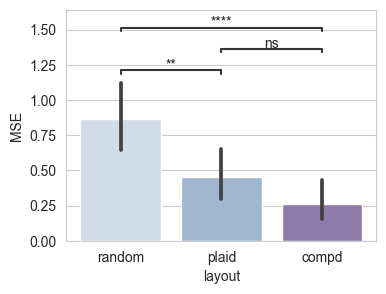

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.372e-02 t=1.796e+00
plaid vs. compd: t-test independent samples, P_val:2.051e-02 t=2.332e+00
random vs. compd: t-test independent samples, P_val:9.389e-06 t=4.529e+00


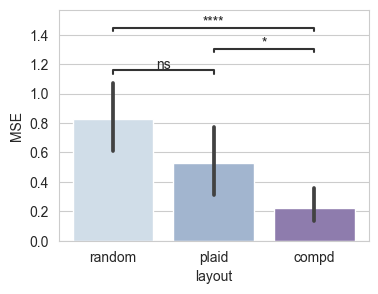

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.092e-03 t=2.827e+00
plaid vs. compd: t-test independent samples, P_val:1.214e-01 t=1.554e+00
random vs. compd: t-test independent samples, P_val:5.322e-05 t=4.116e+00


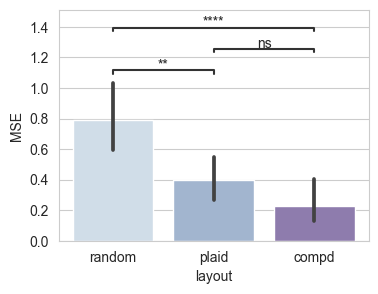

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.366e-03 t=2.620e+00
plaid vs. compd: t-test independent samples, P_val:1.732e-02 t=2.397e+00
random vs. compd: t-test independent samples, P_val:1.194e-06 t=4.985e+00


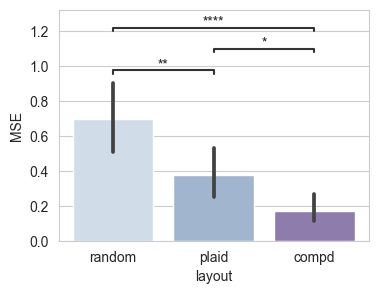

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.298e-02 t=2.289e+00
plaid vs. compd: t-test independent samples, P_val:5.658e-03 t=2.792e+00
random vs. compd: t-test independent samples, P_val:2.383e-06 t=4.836e+00


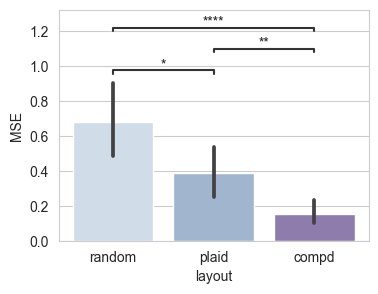

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.494e-02 t=2.121e+00
plaid vs. compd: t-test independent samples, P_val:3.643e-02 t=2.104e+00
random vs. compd: t-test independent samples, P_val:2.300e-05 t=4.319e+00


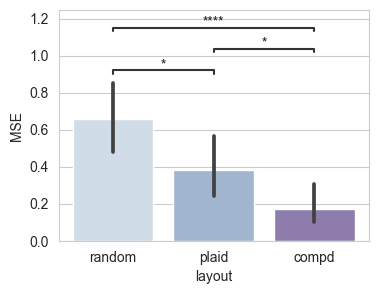

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.838e-03 t=2.782e+00
plaid vs. compd: t-test independent samples, P_val:2.723e-02 t=2.222e+00
random vs. compd: t-test independent samples, P_val:2.704e-06 t=4.808e+00


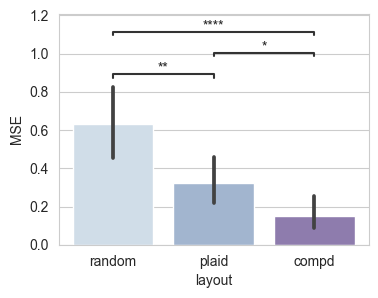

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.221e-02 t=2.525e+00
plaid vs. compd: t-test independent samples, P_val:1.586e-02 t=2.430e+00
random vs. compd: t-test independent samples, P_val:4.656e-06 t=4.688e+00


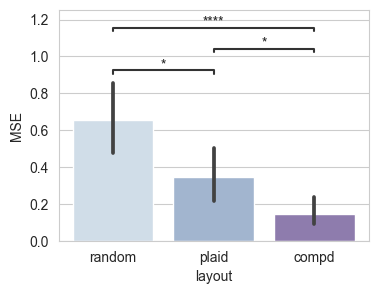

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.804e-02 t=2.210e+00
plaid vs. compd: t-test independent samples, P_val:1.829e-02 t=2.376e+00
random vs. compd: t-test independent samples, P_val:3.317e-05 t=4.231e+00


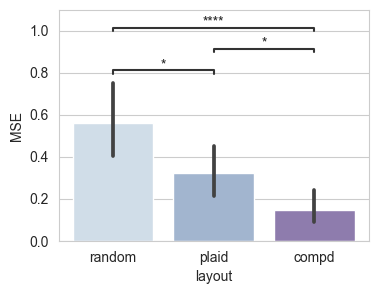

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.897e-02 t=1.979e+00
plaid vs. compd: t-test independent samples, P_val:1.459e-02 t=2.460e+00
random vs. compd: t-test independent samples, P_val:2.691e-05 t=4.282e+00


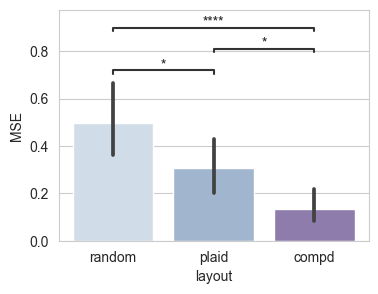

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.389e-02 t=2.134e+00
plaid vs. compd: t-test independent samples, P_val:6.091e-03 t=2.768e+00
random vs. compd: t-test independent samples, P_val:1.886e-06 t=4.887e+00


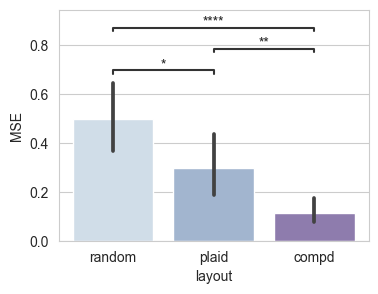

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.830e-03 t=2.845e+00
plaid vs. compd: t-test independent samples, P_val:2.030e-02 t=2.336e+00
random vs. compd: t-test independent samples, P_val:1.451e-06 t=4.943e+00


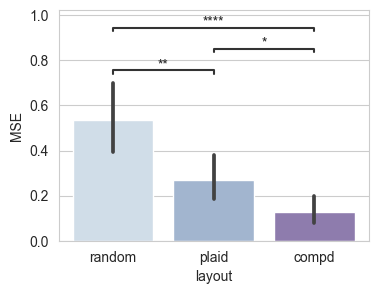

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.162e-01 t=-5.018e-01
plaid vs. compd: t-test independent samples, P_val:3.604e-01 t=-9.164e-01
random vs. compd: t-test independent samples, P_val:2.252e-01 t=-1.216e+00


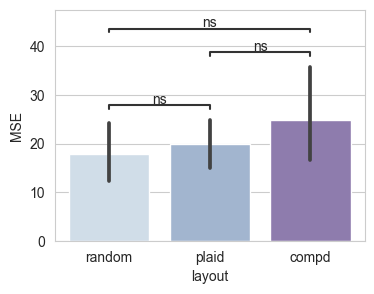

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.641e-01 t=4.505e-02
plaid vs. compd: t-test independent samples, P_val:8.262e-02 t=1.743e+00
random vs. compd: t-test independent samples, P_val:8.656e-03 t=2.647e+00


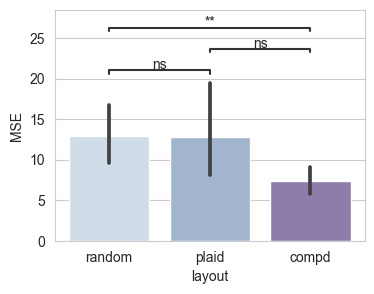

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.049e-01 t=1.271e+00
plaid vs. compd: t-test independent samples, P_val:1.848e-02 t=2.372e+00
random vs. compd: t-test independent samples, P_val:1.001e-03 t=3.331e+00


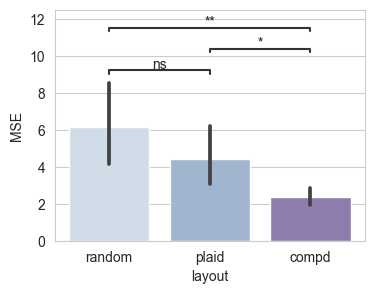

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.112e-02 t=2.168e+00
plaid vs. compd: t-test independent samples, P_val:5.081e-05 t=4.127e+00
random vs. compd: t-test independent samples, P_val:5.409e-04 t=3.507e+00


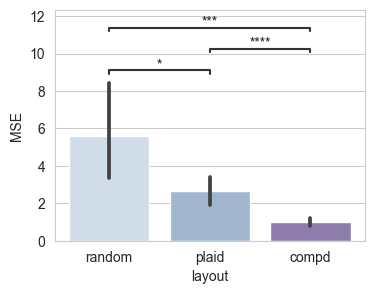

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.547e-02 t=1.785e+00
plaid vs. compd: t-test independent samples, P_val:1.113e-02 t=2.558e+00
random vs. compd: t-test independent samples, P_val:4.419e-07 t=5.194e+00


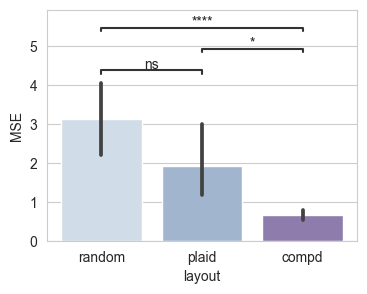

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.019e-02 t=2.338e+00
plaid vs. compd: t-test independent samples, P_val:1.869e-03 t=3.146e+00
random vs. compd: t-test independent samples, P_val:1.252e-05 t=4.462e+00


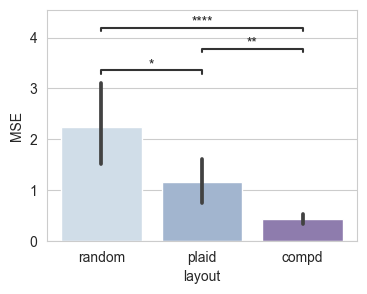

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.571e-02 t=1.849e+00
plaid vs. compd: t-test independent samples, P_val:3.290e-04 t=3.644e+00
random vs. compd: t-test independent samples, P_val:4.485e-06 t=4.696e+00


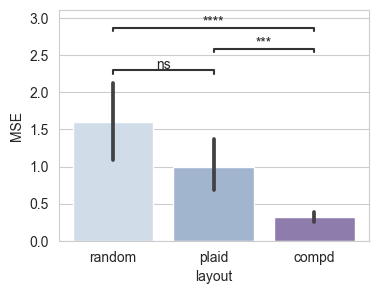

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.643e-01 t=1.395e+00
plaid vs. compd: t-test independent samples, P_val:1.117e-03 t=3.300e+00
random vs. compd: t-test independent samples, P_val:7.761e-05 t=4.022e+00


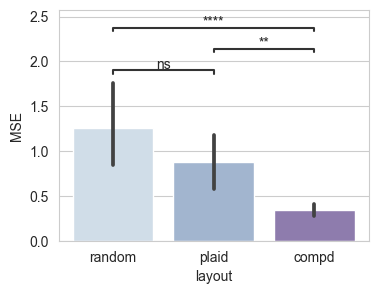

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.899e-02 t=1.979e+00
plaid vs. compd: t-test independent samples, P_val:4.119e-04 t=3.583e+00
random vs. compd: t-test independent samples, P_val:7.095e-05 t=4.044e+00


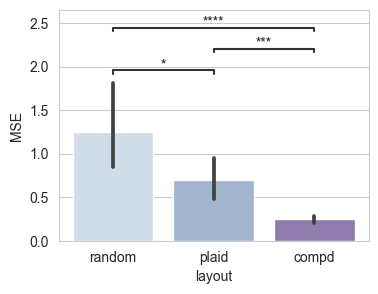

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.141e-02 t=2.165e+00
plaid vs. compd: t-test independent samples, P_val:4.683e-04 t=3.547e+00
random vs. compd: t-test independent samples, P_val:2.001e-05 t=4.352e+00


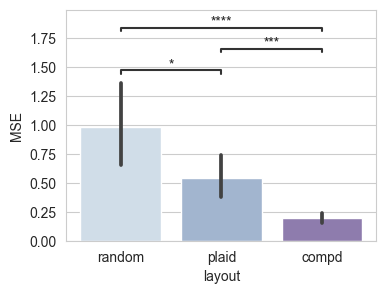

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.558e-02 t=2.247e+00
plaid vs. compd: t-test independent samples, P_val:1.179e-03 t=3.284e+00
random vs. compd: t-test independent samples, P_val:4.018e-05 t=4.185e+00


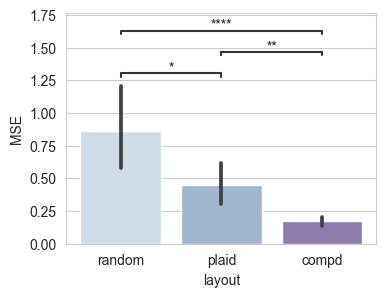

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.501e-02 t=1.854e+00
plaid vs. compd: t-test independent samples, P_val:2.956e-03 t=3.003e+00
random vs. compd: t-test independent samples, P_val:1.067e-04 t=3.941e+00


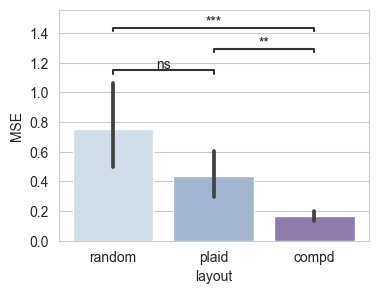

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.385e-02 t=2.480e+00
plaid vs. compd: t-test independent samples, P_val:8.754e-04 t=3.370e+00
random vs. compd: t-test independent samples, P_val:6.042e-05 t=4.084e+00


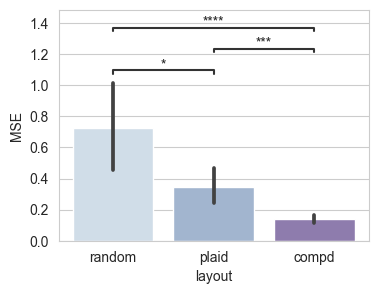

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.989e-02 t=2.066e+00
plaid vs. compd: t-test independent samples, P_val:1.979e-04 t=3.781e+00
random vs. compd: t-test independent samples, P_val:4.794e-06 t=4.681e+00


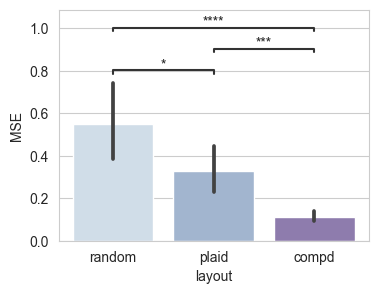

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.012e-02 t=2.064e+00
plaid vs. compd: t-test independent samples, P_val:3.325e-03 t=2.966e+00
random vs. compd: t-test independent samples, P_val:9.766e-06 t=4.520e+00


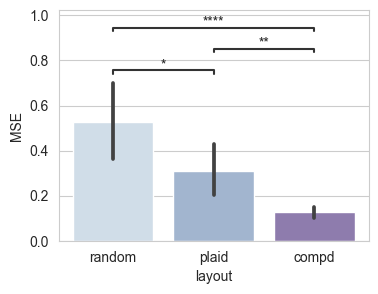

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.608e-02 t=2.424e+00
plaid vs. compd: t-test independent samples, P_val:1.480e-04 t=3.857e+00
random vs. compd: t-test independent samples, P_val:6.536e-06 t=4.611e+00


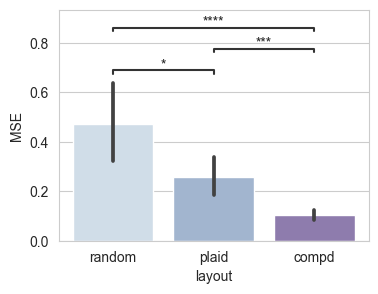

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.625e-02 t=2.236e+00
plaid vs. compd: t-test independent samples, P_val:3.781e-04 t=3.606e+00
random vs. compd: t-test independent samples, P_val:1.299e-07 t=5.443e+00


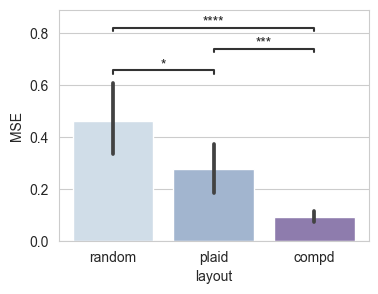

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.380e-02 t=1.736e+00
plaid vs. compd: t-test independent samples, P_val:6.469e-04 t=3.457e+00
random vs. compd: t-test independent samples, P_val:1.555e-05 t=4.412e+00


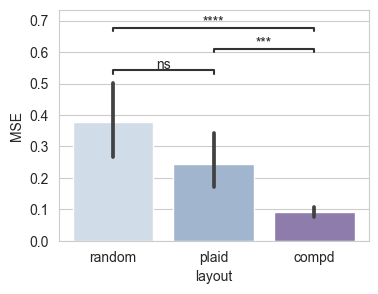

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.072e-01 t=1.617e+00
plaid vs. compd: t-test independent samples, P_val:1.078e-03 t=3.310e+00
random vs. compd: t-test independent samples, P_val:5.676e-06 t=4.643e+00


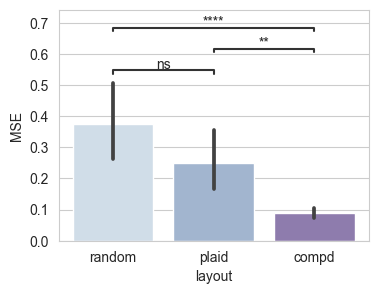

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.759e-02 t=1.908e+00
plaid vs. compd: t-test independent samples, P_val:2.391e-03 t=3.070e+00
random vs. compd: t-test independent samples, P_val:5.016e-06 t=4.671e+00


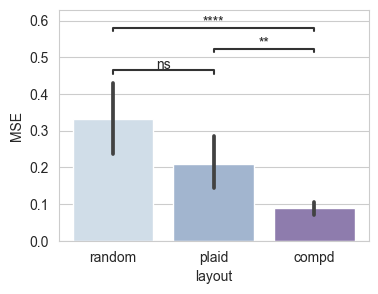

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.899e-02 t=2.362e+00
plaid vs. compd: t-test independent samples, P_val:9.747e-05 t=3.964e+00
random vs. compd: t-test independent samples, P_val:7.852e-06 t=4.570e+00


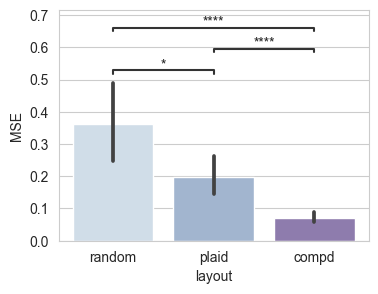

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.679e-02 t=2.100e+00
plaid vs. compd: t-test independent samples, P_val:6.643e-04 t=3.449e+00
random vs. compd: t-test independent samples, P_val:3.682e-05 t=4.206e+00


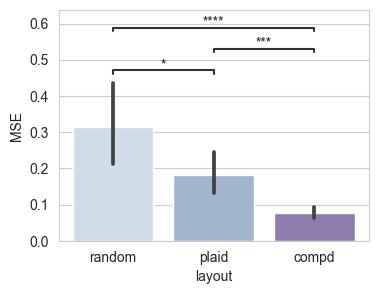

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.919e-02 t=1.896e+00
plaid vs. compd: t-test independent samples, P_val:6.472e-04 t=3.457e+00
random vs. compd: t-test independent samples, P_val:7.573e-06 t=4.578e+00


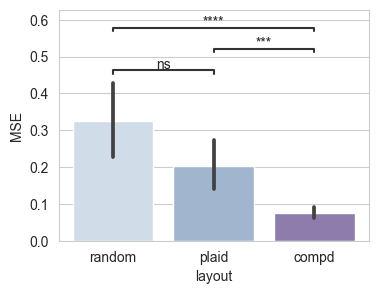

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.396e-02 t=1.682e+00
plaid vs. compd: t-test independent samples, P_val:1.600e-03 t=3.193e+00
random vs. compd: t-test independent samples, P_val:3.524e-06 t=4.750e+00


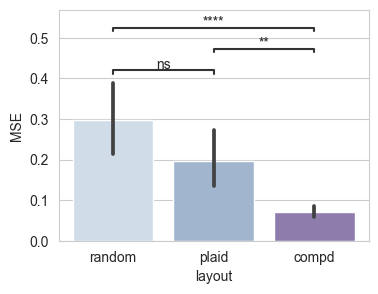

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.468e-03 t=2.804e+00
plaid vs. compd: t-test independent samples, P_val:8.989e-04 t=3.363e+00
random vs. compd: t-test independent samples, P_val:8.186e-07 t=5.065e+00


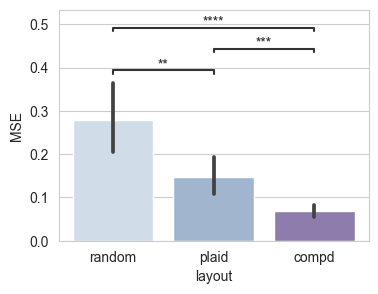

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.540e-02 t=2.249e+00
plaid vs. compd: t-test independent samples, P_val:2.408e-03 t=3.068e+00
random vs. compd: t-test independent samples, P_val:2.517e-05 t=4.298e+00


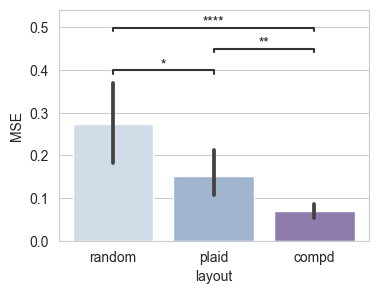

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.571e-02 t=-1.923e+00
plaid vs. compd: t-test independent samples, P_val:2.430e-02 t=2.267e+00
random vs. compd: t-test independent samples, P_val:7.995e-01 t=2.543e-01


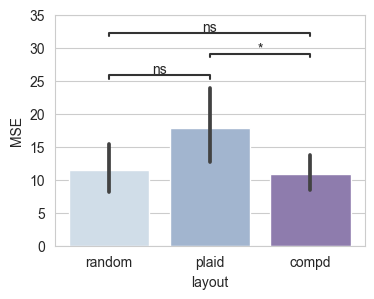

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.343e-02 t=1.941e+00
plaid vs. compd: t-test independent samples, P_val:5.478e-01 t=6.019e-01
random vs. compd: t-test independent samples, P_val:1.340e-02 t=2.492e+00


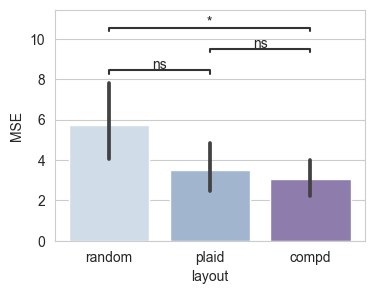

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.604e-03 t=3.192e+00
plaid vs. compd: t-test independent samples, P_val:8.733e-02 t=-1.717e+00
random vs. compd: t-test independent samples, P_val:6.512e-02 t=1.853e+00


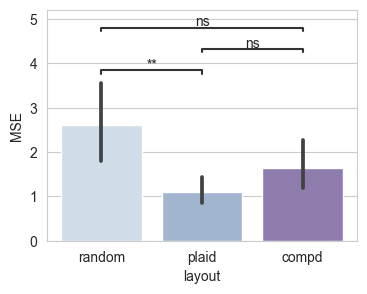

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.696e-04 t=3.821e+00
plaid vs. compd: t-test independent samples, P_val:3.663e-02 t=-2.102e+00
random vs. compd: t-test independent samples, P_val:3.000e-03 t=2.999e+00


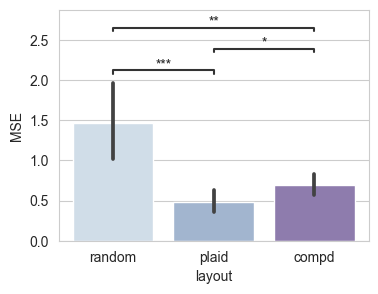

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.076e-02 t=2.571e+00
plaid vs. compd: t-test independent samples, P_val:4.321e-03 t=-2.881e+00
random vs. compd: t-test independent samples, P_val:4.092e-02 t=2.056e+00


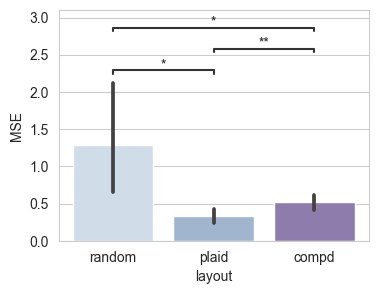

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.441e-03 t=2.656e+00
plaid vs. compd: t-test independent samples, P_val:6.469e-03 t=-2.747e+00
random vs. compd: t-test independent samples, P_val:2.118e-02 t=2.320e+00


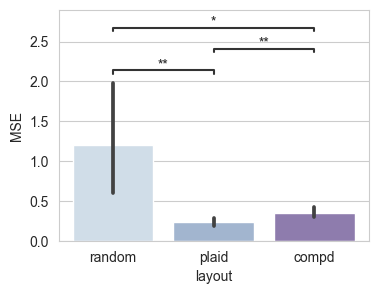

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.160e-03 t=2.894e+00
plaid vs. compd: t-test independent samples, P_val:5.759e-03 t=-2.786e+00
random vs. compd: t-test independent samples, P_val:1.145e-02 t=2.548e+00


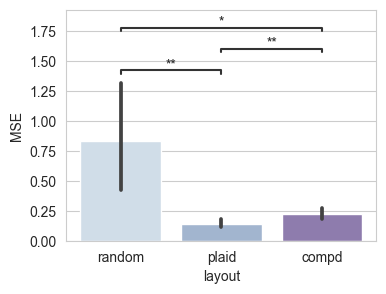

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.337e-02 t=2.492e+00
plaid vs. compd: t-test independent samples, P_val:3.483e-02 t=-2.123e+00
random vs. compd: t-test independent samples, P_val:2.528e-02 t=2.251e+00


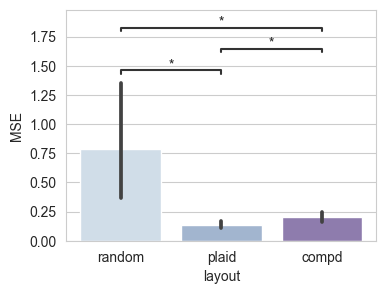

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.100e-02 t=2.563e+00
plaid vs. compd: t-test independent samples, P_val:1.128e-03 t=-3.297e+00
random vs. compd: t-test independent samples, P_val:3.054e-02 t=2.176e+00


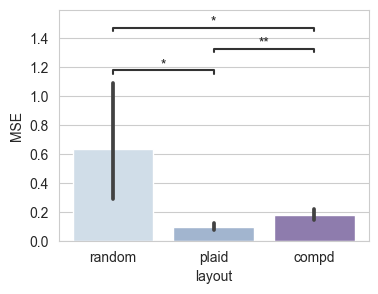

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.357e-02 t=2.487e+00
plaid vs. compd: t-test independent samples, P_val:3.186e-04 t=-3.653e+00
random vs. compd: t-test independent samples, P_val:3.525e-02 t=2.118e+00


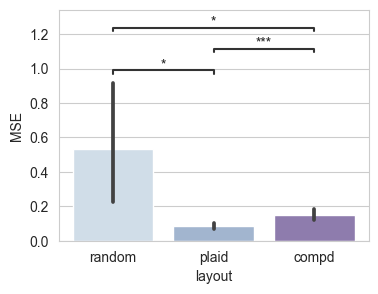

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.772e-03 t=2.786e+00
plaid vs. compd: t-test independent samples, P_val:2.630e-03 t=-3.040e+00
random vs. compd: t-test independent samples, P_val:1.820e-02 t=2.378e+00


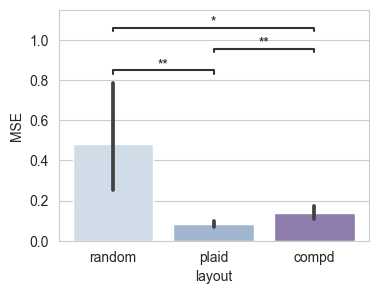

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.365e-03 t=2.753e+00
plaid vs. compd: t-test independent samples, P_val:7.212e-06 t=-4.589e+00
random vs. compd: t-test independent samples, P_val:2.242e-02 t=2.298e+00


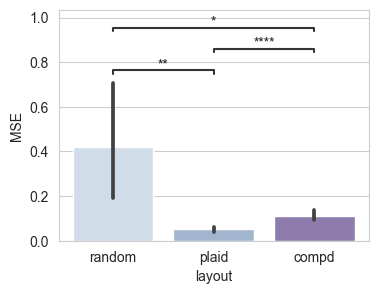

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.636e-03 t=2.648e+00
plaid vs. compd: t-test independent samples, P_val:1.444e-02 t=-2.464e+00
random vs. compd: t-test independent samples, P_val:1.768e-02 t=2.389e+00


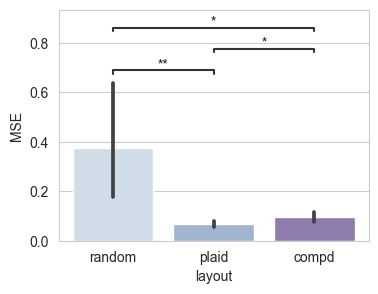

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.847e-03 t=2.728e+00
plaid vs. compd: t-test independent samples, P_val:1.449e-03 t=-3.222e+00
random vs. compd: t-test independent samples, P_val:2.109e-02 t=2.322e+00


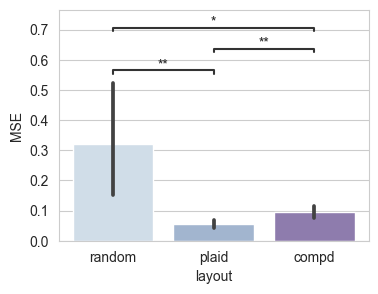

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.059e-02 t=2.576e+00
plaid vs. compd: t-test independent samples, P_val:2.878e-02 t=-2.200e+00
random vs. compd: t-test independent samples, P_val:2.088e-02 t=2.326e+00


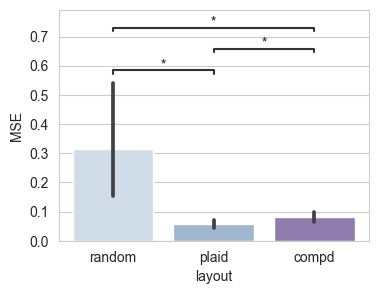

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.416e-03 t=2.618e+00
plaid vs. compd: t-test independent samples, P_val:4.735e-02 t=-1.993e+00
random vs. compd: t-test independent samples, P_val:1.749e-02 t=2.393e+00


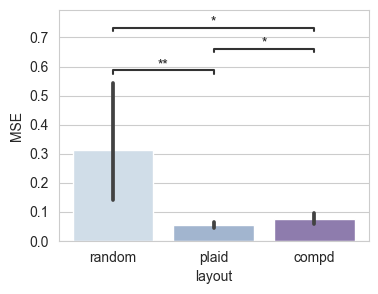

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.915e-03 t=2.600e+00
plaid vs. compd: t-test independent samples, P_val:7.896e-04 t=-3.400e+00
random vs. compd: t-test independent samples, P_val:2.470e-02 t=2.260e+00


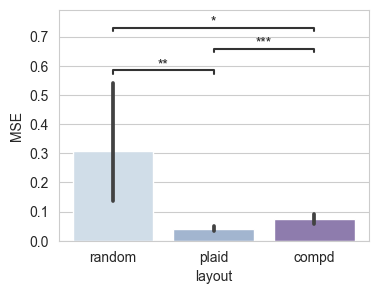

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.065e-02 t=2.574e+00
plaid vs. compd: t-test independent samples, P_val:4.228e-02 t=-2.042e+00
random vs. compd: t-test independent samples, P_val:1.858e-02 t=2.370e+00


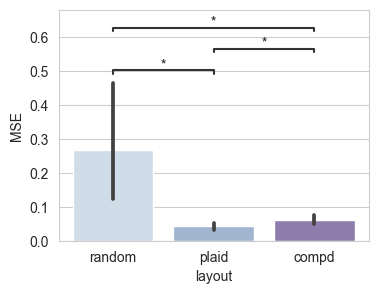

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.602e-03 t=2.740e+00
plaid vs. compd: t-test independent samples, P_val:5.586e-02 t=-1.922e+00
random vs. compd: t-test independent samples, P_val:1.208e-02 t=2.529e+00


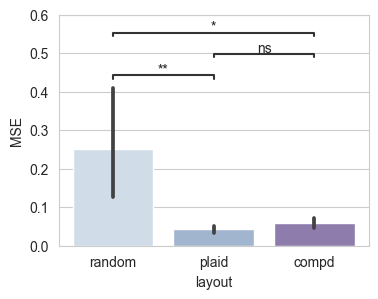

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.041e-02 t=2.583e+00
plaid vs. compd: t-test independent samples, P_val:3.902e-03 t=-2.914e+00
random vs. compd: t-test independent samples, P_val:2.194e-02 t=2.307e+00


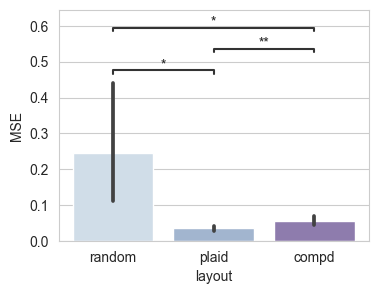

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.722e-02 t=2.399e+00
plaid vs. compd: t-test independent samples, P_val:1.046e-01 t=-1.629e+00
random vs. compd: t-test independent samples, P_val:2.836e-02 t=2.206e+00


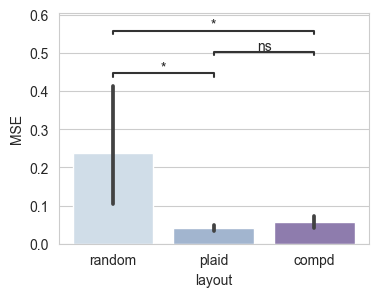

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.014e-02 t=2.592e+00
plaid vs. compd: t-test independent samples, P_val:7.104e-02 t=-1.813e+00
random vs. compd: t-test independent samples, P_val:1.727e-02 t=2.398e+00


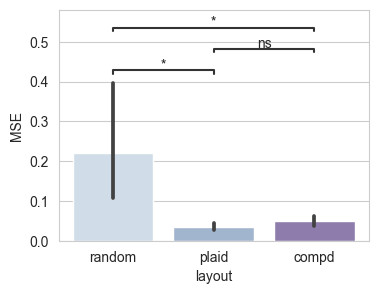

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.314e-02 t=2.499e+00
plaid vs. compd: t-test independent samples, P_val:1.803e-02 t=-2.381e+00
random vs. compd: t-test independent samples, P_val:2.450e-02 t=2.264e+00


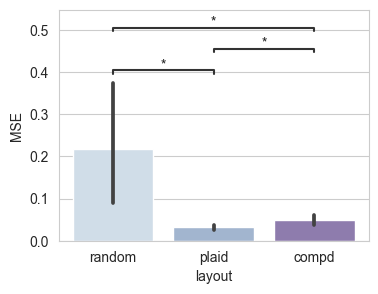

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.058e-02 t=2.577e+00
plaid vs. compd: t-test independent samples, P_val:4.980e-01 t=-6.787e-01
random vs. compd: t-test independent samples, P_val:1.296e-02 t=2.504e+00


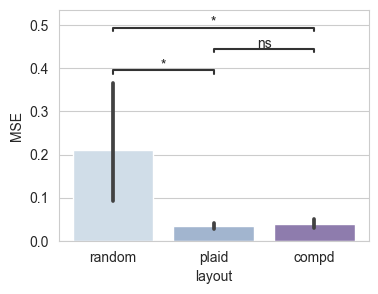

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.288e-02 t=2.506e+00
plaid vs. compd: t-test independent samples, P_val:6.321e-02 t=-1.866e+00
random vs. compd: t-test independent samples, P_val:2.108e-02 t=2.322e+00


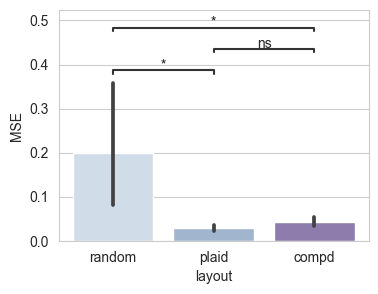

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.157e-02 t=2.313e+00
plaid vs. compd: t-test independent samples, P_val:1.264e-03 t=-3.263e+00
random vs. compd: t-test independent samples, P_val:4.609e-02 t=2.005e+00


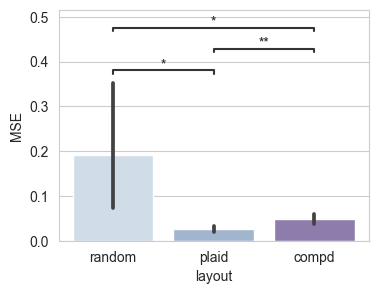

In [10]:
for screening_scores_data_filename in output_file_list:
    util.plotting_residual_metrics(data_directory+screening_scores_data_filename,metric='SSMD',
                                   fig_name=screening_scores_data_filename,
                                   y_max = None,
                                   palette = sns.color_palette("BuPu",4),
                                   plots_directory = plots_directory,
                                   box_pairs = [("random", "plaid"),
                                                ("random", "compd"),
                                                ("plaid", "compd")
                                               ],
                                   order = ["random","plaid","compd"]
#                                   box_pairs = [("border", "random"),
#                                                ("border", "plaid"),
#                                                ("border", "compd"),
#                                                ("random", "plaid"),
#                                                ("random", "compd"),
#                                                ("plaid", "compd")
#                                               ],
#                                   order = ["border","random","plaid","compd"]
                                  )


## Plots in the manuscript

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.291e-01 t=1.523e+00
plaid vs. compd: t-test independent samples, P_val:3.552e-03 t=2.945e+00
random vs. compd: t-test independent samples, P_val:9.787e-05 t=3.963e+00


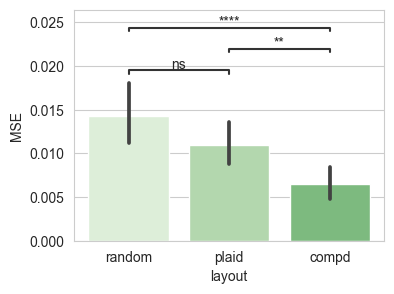

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.571e-02 t=1.849e+00
plaid vs. compd: t-test independent samples, P_val:3.290e-04 t=3.644e+00
random vs. compd: t-test independent samples, P_val:4.485e-06 t=4.696e+00


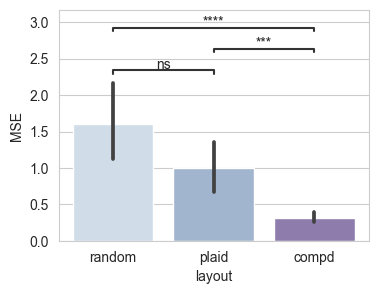

In [31]:
screening_scores_data_filename = 'screening_metrics_data-10-10-0.06-20250623-reviewing.csv'

util.plotting_residual_metrics(data_directory+screening_scores_data_filename,metric='Zfactor',
                               fig_name='manuscript', y_max = None, plots_directory = plots_directory,
                               box_pairs = [   ("random", "plaid"),
                                                ("random", "compd"),
                                                ("plaid", "compd")
                                               ],
                                order = ["random","plaid","compd"])
util.plotting_residual_metrics(data_directory+screening_scores_data_filename,metric='SSMD', fig_name='manuscript', y_max = None,
                               palette = sns.color_palette("BuPu",4), plots_directory = plots_directory,
                                box_pairs = [   ("random", "plaid"),
                                                ("random", "compd"),
                                                ("plaid", "compd")
                                               ],
                                order = ["random","plaid","compd"])



## Plotting the supplement data

First we plot the Z' factor MSE. Note that we fixed the y_max parameter so that all plots have the same y axis in a suitable way for the supplement.

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.488e-01 t=-7.587e-01
plaid vs. compd: t-test independent samples, P_val:6.080e-01 t=-5.136e-01
random vs. compd: t-test independent samples, P_val:2.109e-01 t=-1.255e+00


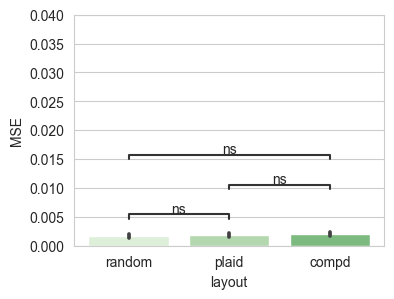

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.486e-01 t=1.911e-01
plaid vs. compd: t-test independent samples, P_val:4.683e-01 t=7.265e-01
random vs. compd: t-test independent samples, P_val:3.226e-01 t=9.912e-01


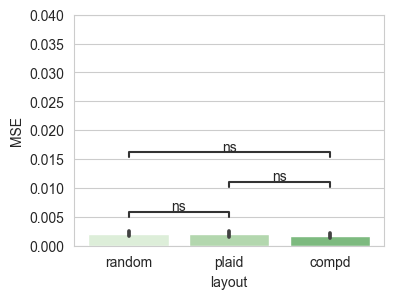

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.176e-03 t=2.822e+00
plaid vs. compd: t-test independent samples, P_val:1.373e-01 t=1.491e+00
random vs. compd: t-test independent samples, P_val:3.087e-05 t=4.249e+00


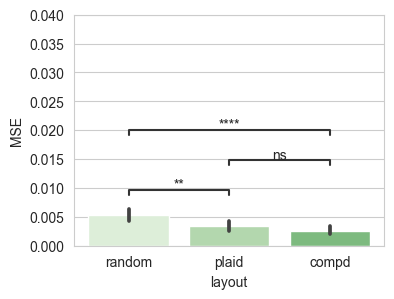

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.926e-02 t=2.357e+00
plaid vs. compd: t-test independent samples, P_val:9.069e-01 t=-1.170e-01
random vs. compd: t-test independent samples, P_val:3.214e-02 t=2.155e+00


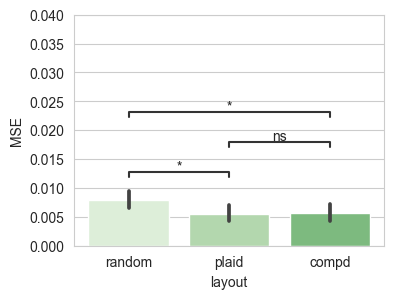

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.497e-02 t=2.121e+00
plaid vs. compd: t-test independent samples, P_val:1.173e-01 t=1.572e+00
random vs. compd: t-test independent samples, P_val:1.400e-04 t=3.871e+00


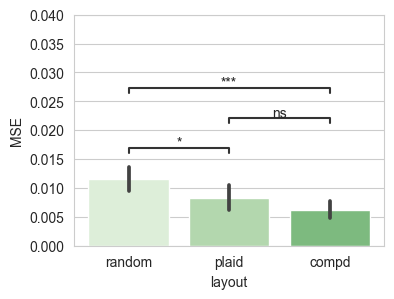

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.734e-04 t=3.340e+00
plaid vs. compd: t-test independent samples, P_val:8.025e-01 t=2.504e-01
random vs. compd: t-test independent samples, P_val:7.374e-04 t=3.420e+00


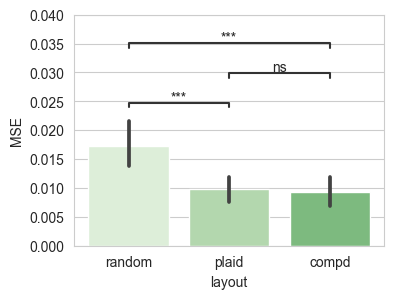

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.724e-05 t=4.387e+00
plaid vs. compd: t-test independent samples, P_val:8.010e-01 t=-2.524e-01
random vs. compd: t-test independent samples, P_val:3.296e-04 t=3.644e+00


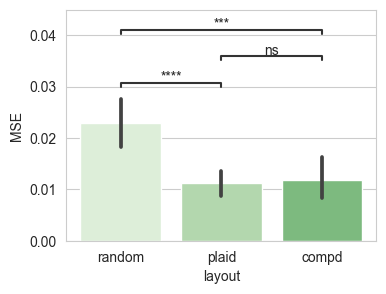

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.468e-03 t=2.952e+00
plaid vs. compd: t-test independent samples, P_val:3.383e-01 t=9.595e-01
random vs. compd: t-test independent samples, P_val:1.876e-04 t=3.795e+00


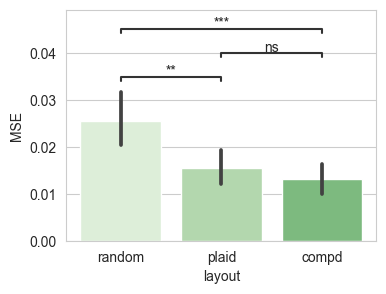

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.024e-04 t=3.952e+00
plaid vs. compd: t-test independent samples, P_val:9.542e-01 t=5.744e-02
random vs. compd: t-test independent samples, P_val:1.217e-04 t=3.907e+00


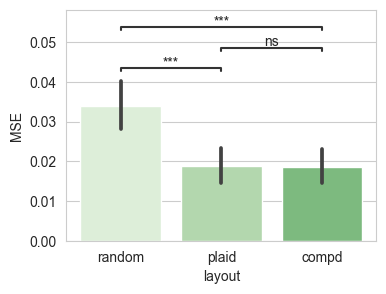

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.765e-03 t=2.849e+00
plaid vs. compd: t-test independent samples, P_val:2.639e-01 t=1.120e+00
random vs. compd: t-test independent samples, P_val:1.372e-04 t=3.876e+00


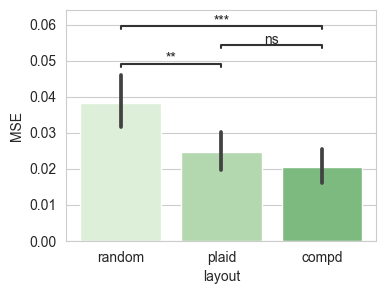

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.683e-03 t=2.933e+00
plaid vs. compd: t-test independent samples, P_val:1.023e-01 t=1.640e+00
random vs. compd: t-test independent samples, P_val:8.030e-06 t=4.564e+00


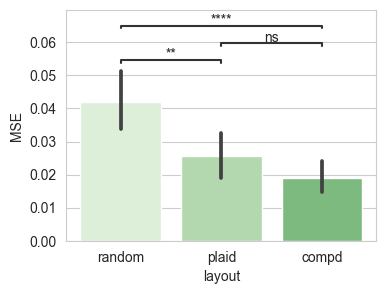

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.875e-03 t=3.145e+00
plaid vs. compd: t-test independent samples, P_val:1.165e-01 t=1.575e+00
random vs. compd: t-test independent samples, P_val:5.696e-06 t=4.642e+00


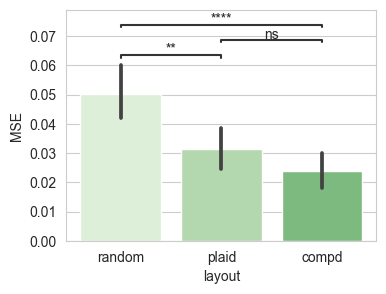

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.046e-04 t=3.433e+00
plaid vs. compd: t-test independent samples, P_val:5.115e-02 t=1.960e+00
random vs. compd: t-test independent samples, P_val:6.881e-07 t=5.102e+00


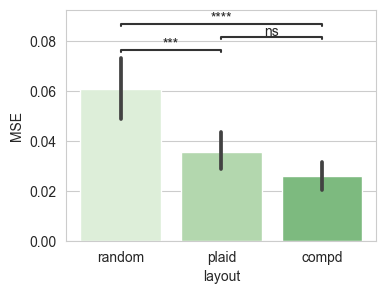

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.443e-04 t=3.417e+00
plaid vs. compd: t-test independent samples, P_val:1.731e-01 t=1.367e+00
random vs. compd: t-test independent samples, P_val:1.466e-05 t=4.425e+00


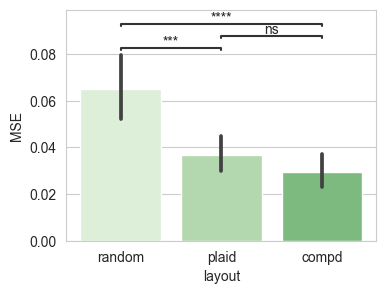

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.238e-03 t=3.269e+00
plaid vs. compd: t-test independent samples, P_val:7.197e-01 t=3.592e-01
random vs. compd: t-test independent samples, P_val:3.433e-04 t=3.633e+00


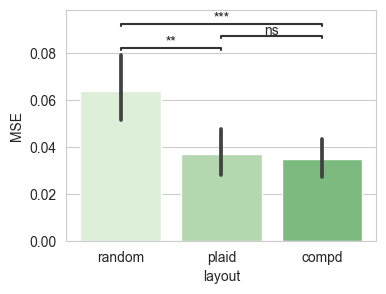

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.853e-03 t=2.639e+00
plaid vs. compd: t-test independent samples, P_val:1.134e-01 t=1.589e+00
random vs. compd: t-test independent samples, P_val:1.616e-05 t=4.403e+00


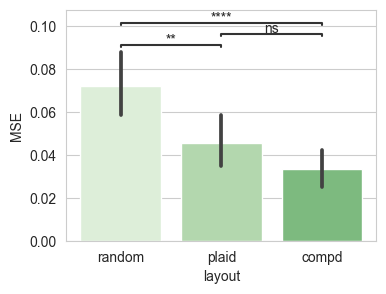

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.300e-04 t=3.423e+00
plaid vs. compd: t-test independent samples, P_val:4.436e-01 t=7.674e-01
random vs. compd: t-test independent samples, P_val:6.622e-05 t=4.061e+00


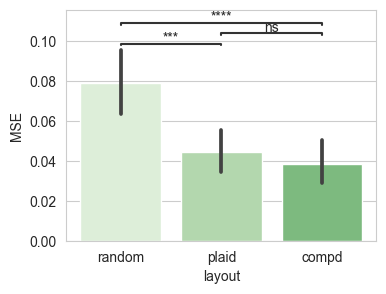

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.565e-03 t=3.199e+00
plaid vs. compd: t-test independent samples, P_val:4.861e-02 t=1.982e+00
random vs. compd: t-test independent samples, P_val:5.177e-06 t=4.664e+00


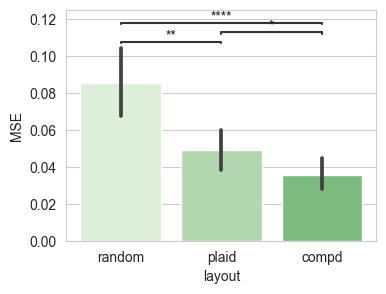

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.620e-03 t=3.189e+00
plaid vs. compd: t-test independent samples, P_val:8.313e-02 t=1.740e+00
random vs. compd: t-test independent samples, P_val:2.161e-05 t=4.334e+00


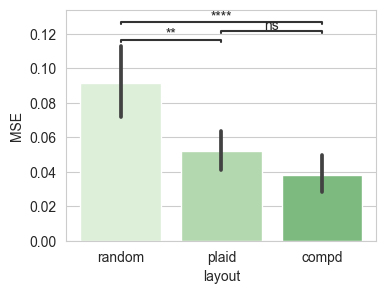

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.314e-03 t=2.967e+00
plaid vs. compd: t-test independent samples, P_val:2.915e-01 t=1.057e+00
random vs. compd: t-test independent samples, P_val:2.598e-04 t=3.708e+00


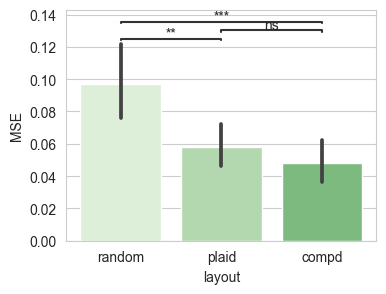

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.685e-04 t=3.493e+00
plaid vs. compd: t-test independent samples, P_val:2.093e-01 t=1.259e+00
random vs. compd: t-test independent samples, P_val:1.437e-05 t=4.430e+00


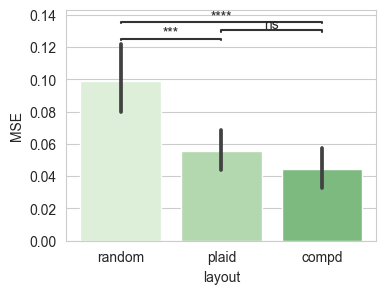

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.156e-03 t=3.102e+00
plaid vs. compd: t-test independent samples, P_val:4.003e-02 t=2.065e+00
random vs. compd: t-test independent samples, P_val:5.090e-06 t=4.668e+00


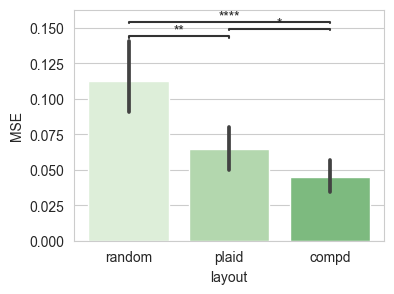

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.839e-03 t=2.682e+00
plaid vs. compd: t-test independent samples, P_val:1.075e-01 t=1.616e+00
random vs. compd: t-test independent samples, P_val:1.233e-04 t=3.904e+00


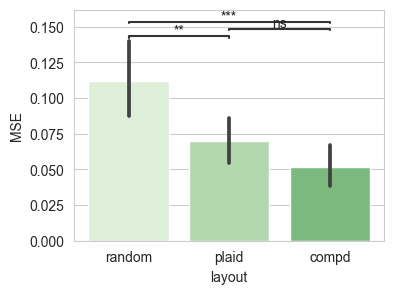

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.312e-02 t=2.499e+00
plaid vs. compd: t-test independent samples, P_val:2.887e-02 t=2.199e+00
random vs. compd: t-test independent samples, P_val:4.011e-05 t=4.185e+00


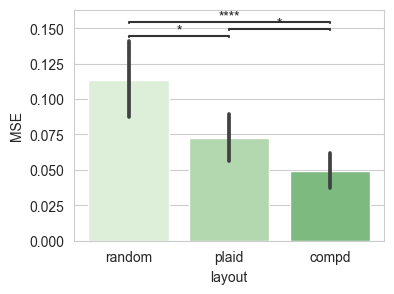

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.230e-03 t=2.819e+00
plaid vs. compd: t-test independent samples, P_val:1.264e-02 t=2.513e+00
random vs. compd: t-test independent samples, P_val:9.667e-06 t=4.522e+00


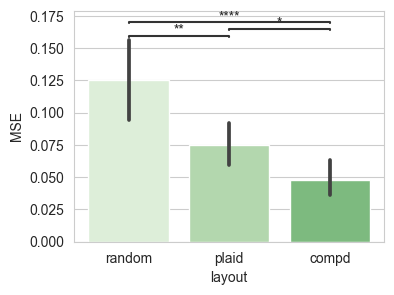

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.091e-03 t=3.306e+00
plaid vs. compd: t-test independent samples, P_val:5.073e-01 t=6.640e-01
random vs. compd: t-test independent samples, P_val:2.500e-04 t=3.718e+00


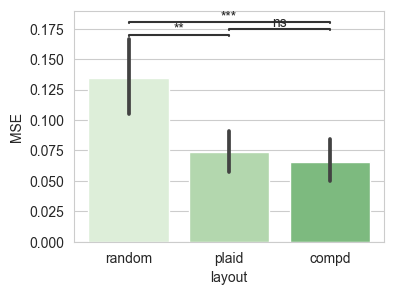

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.567e-01 t=-5.886e-01
plaid vs. compd: t-test independent samples, P_val:7.068e-01 t=-3.767e-01
random vs. compd: t-test independent samples, P_val:3.909e-01 t=-8.595e-01


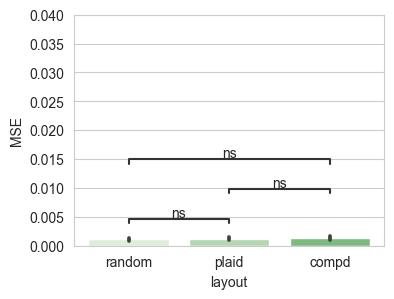

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.363e-01 t=3.371e-01
plaid vs. compd: t-test independent samples, P_val:8.304e-01 t=2.144e-01
random vs. compd: t-test independent samples, P_val:5.517e-01 t=5.961e-01


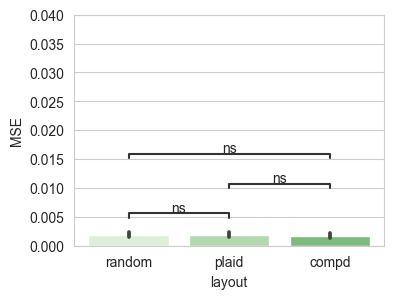

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.378e-01 t=7.772e-01
plaid vs. compd: t-test independent samples, P_val:8.249e-01 t=2.214e-01
random vs. compd: t-test independent samples, P_val:3.443e-01 t=9.477e-01


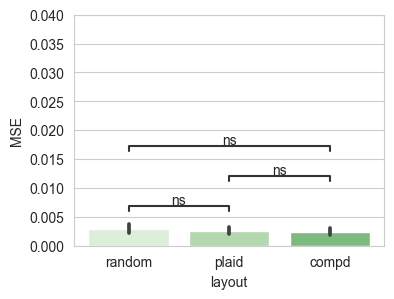

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.221e-01 t=1.552e+00
plaid vs. compd: t-test independent samples, P_val:2.014e-03 t=3.123e+00
random vs. compd: t-test independent samples, P_val:3.872e-04 t=3.600e+00


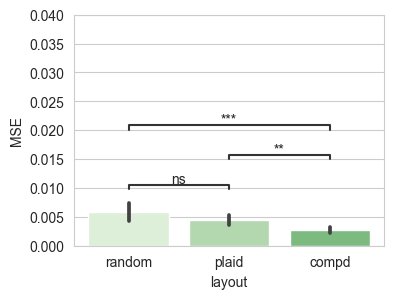

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.151e-02 t=2.050e+00
plaid vs. compd: t-test independent samples, P_val:4.070e-02 t=2.058e+00
random vs. compd: t-test independent samples, P_val:1.345e-04 t=3.881e+00


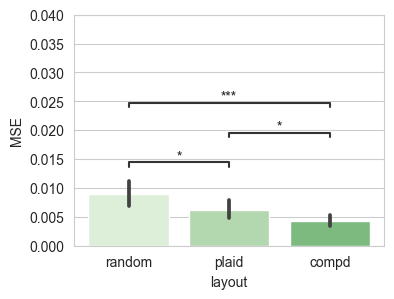

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.432e-03 t=3.065e+00
plaid vs. compd: t-test independent samples, P_val:1.140e-01 t=1.586e+00
random vs. compd: t-test independent samples, P_val:3.495e-05 t=4.219e+00


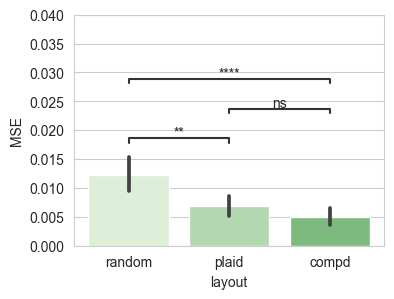

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.291e-01 t=1.523e+00
plaid vs. compd: t-test independent samples, P_val:3.552e-03 t=2.945e+00
random vs. compd: t-test independent samples, P_val:9.787e-05 t=3.963e+00


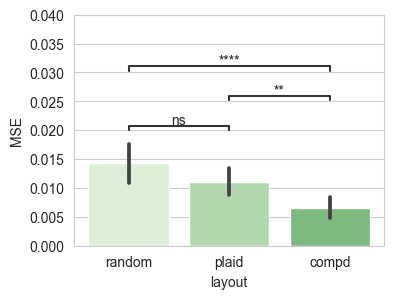

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.128e-01 t=1.592e+00
plaid vs. compd: t-test independent samples, P_val:6.095e-02 t=1.883e+00
random vs. compd: t-test independent samples, P_val:8.161e-04 t=3.391e+00


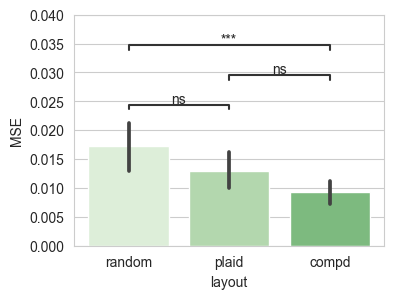

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.607e-02 t=2.239e+00
plaid vs. compd: t-test independent samples, P_val:3.009e-03 t=2.998e+00
random vs. compd: t-test independent samples, P_val:1.109e-05 t=4.490e+00


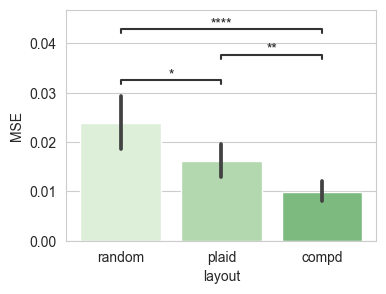

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.725e-03 t=3.029e+00
plaid vs. compd: t-test independent samples, P_val:8.572e-02 t=1.726e+00
random vs. compd: t-test independent samples, P_val:3.196e-05 t=4.240e+00


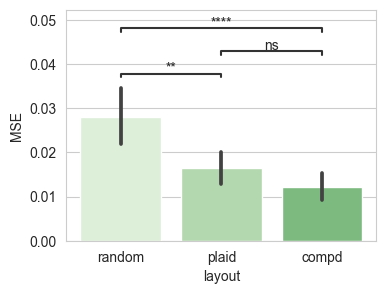

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.416e-03 t=2.750e+00
plaid vs. compd: t-test independent samples, P_val:1.212e-01 t=1.555e+00
random vs. compd: t-test independent samples, P_val:7.870e-05 t=4.018e+00


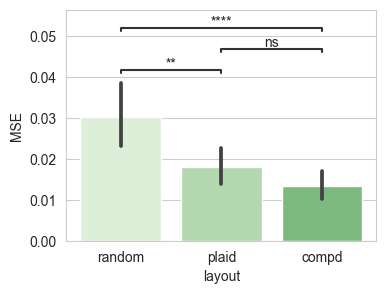

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.059e-02 t=2.331e+00
plaid vs. compd: t-test independent samples, P_val:6.364e-02 t=1.863e+00
random vs. compd: t-test independent samples, P_val:4.981e-04 t=3.530e+00


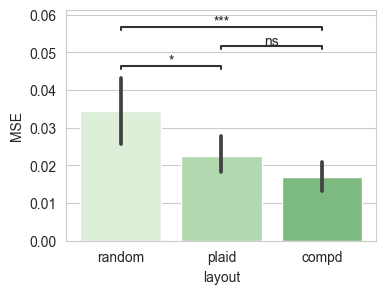

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.033e-03 t=2.995e+00
plaid vs. compd: t-test independent samples, P_val:2.978e-01 t=1.043e+00
random vs. compd: t-test independent samples, P_val:3.657e-04 t=3.616e+00


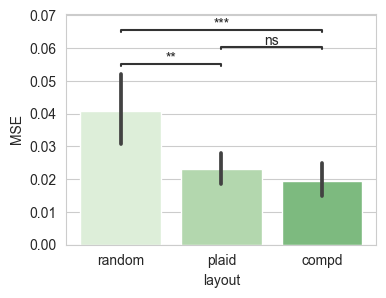

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.503e-03 t=3.055e+00
plaid vs. compd: t-test independent samples, P_val:8.924e-03 t=2.637e+00
random vs. compd: t-test independent samples, P_val:8.509e-07 t=5.057e+00


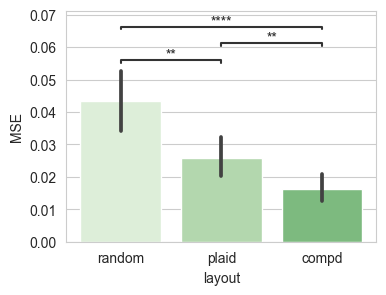

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.297e-02 t=2.289e+00
plaid vs. compd: t-test independent samples, P_val:2.577e-01 t=1.135e+00
random vs. compd: t-test independent samples, P_val:9.772e-04 t=3.339e+00


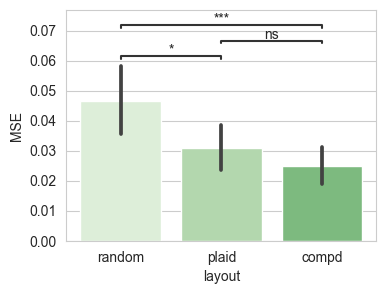

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.530e-03 t=2.947e+00
plaid vs. compd: t-test independent samples, P_val:4.582e-02 t=2.008e+00
random vs. compd: t-test independent samples, P_val:2.249e-05 t=4.325e+00


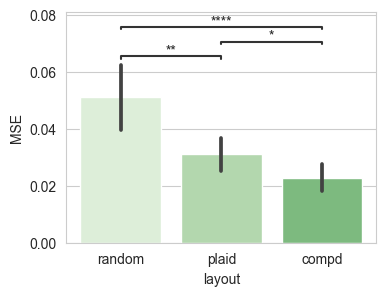

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.122e-03 t=3.107e+00
plaid vs. compd: t-test independent samples, P_val:2.999e-02 t=2.183e+00
random vs. compd: t-test independent samples, P_val:1.693e-06 t=4.910e+00


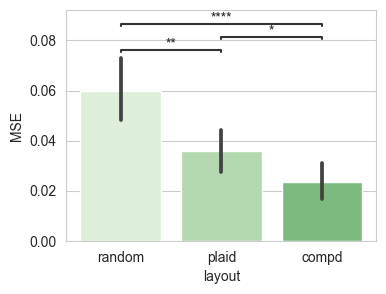

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.356e-02 t=2.279e+00
plaid vs. compd: t-test independent samples, P_val:4.764e-02 t=1.991e+00
random vs. compd: t-test independent samples, P_val:9.622e-05 t=3.967e+00


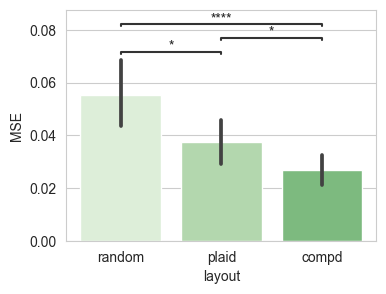

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.187e-02 t=2.046e+00
plaid vs. compd: t-test independent samples, P_val:3.715e-02 t=2.096e+00
random vs. compd: t-test independent samples, P_val:7.661e-05 t=4.025e+00


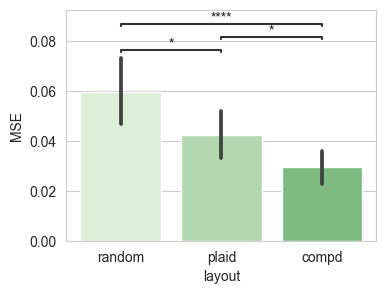

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.727e-02 t=2.398e+00
plaid vs. compd: t-test independent samples, P_val:8.678e-02 t=1.720e+00
random vs. compd: t-test independent samples, P_val:2.143e-04 t=3.760e+00


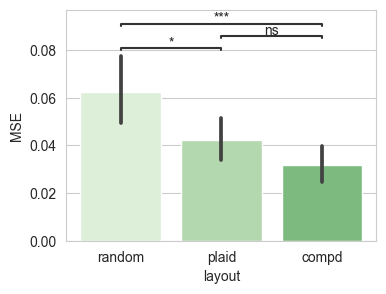

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.325e-04 t=3.385e+00
plaid vs. compd: t-test independent samples, P_val:3.747e-02 t=2.092e+00
random vs. compd: t-test independent samples, P_val:2.739e-06 t=4.805e+00


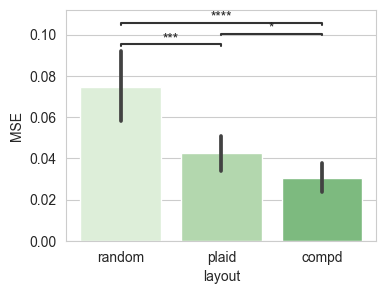

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.483e-03 t=2.654e+00
plaid vs. compd: t-test independent samples, P_val:1.486e-02 t=2.454e+00
random vs. compd: t-test independent samples, P_val:2.986e-05 t=4.257e+00


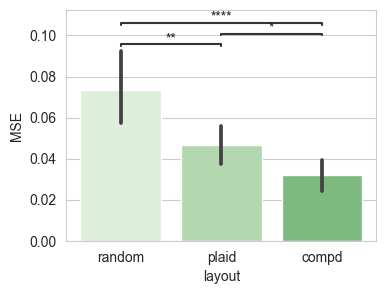

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.158e-02 t=2.313e+00
plaid vs. compd: t-test independent samples, P_val:2.605e-02 t=2.240e+00
random vs. compd: t-test independent samples, P_val:3.041e-05 t=4.252e+00


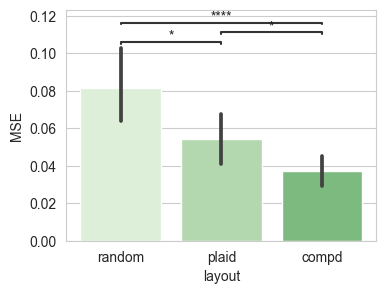

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.443e-02 t=2.265e+00
plaid vs. compd: t-test independent samples, P_val:1.462e-01 t=1.458e+00
random vs. compd: t-test independent samples, P_val:3.868e-04 t=3.600e+00


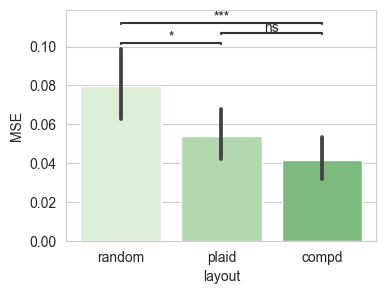

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.452e-04 t=3.417e+00
plaid vs. compd: t-test independent samples, P_val:9.758e-02 t=1.663e+00
random vs. compd: t-test independent samples, P_val:6.073e-06 t=4.628e+00


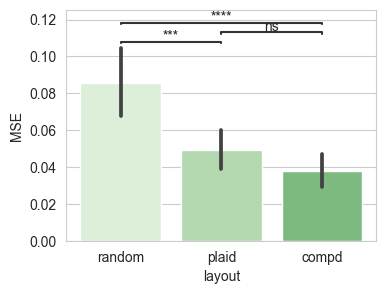

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.688e-03 t=2.933e+00
plaid vs. compd: t-test independent samples, P_val:4.380e-01 t=7.770e-01
random vs. compd: t-test independent samples, P_val:5.380e-04 t=3.509e+00


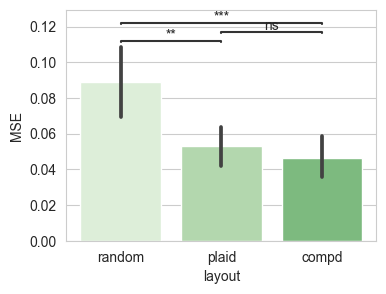

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.036e-02 t=-1.887e+00
plaid vs. compd: t-test independent samples, P_val:5.423e-02 t=1.935e+00
random vs. compd: t-test independent samples, P_val:9.742e-01 t=-3.232e-02


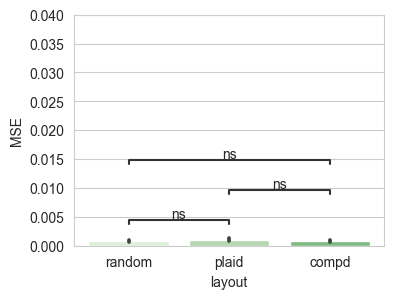

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.493e-01 t=1.447e+00
plaid vs. compd: t-test independent samples, P_val:6.897e-01 t=3.998e-01
random vs. compd: t-test independent samples, P_val:5.098e-02 t=1.962e+00


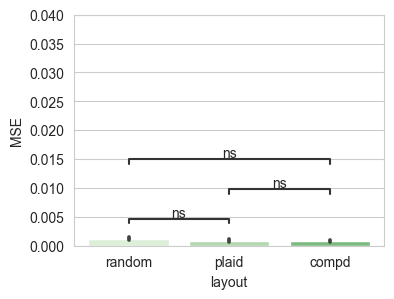

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.211e-02 t=1.746e+00
plaid vs. compd: t-test independent samples, P_val:1.221e-01 t=-1.552e+00
random vs. compd: t-test independent samples, P_val:7.904e-01 t=2.660e-01


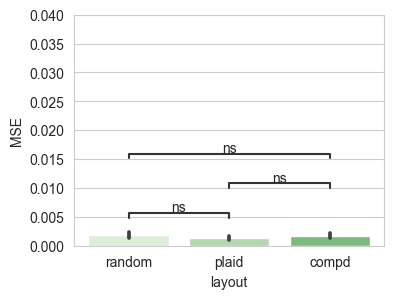

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.725e-04 t=3.695e+00
plaid vs. compd: t-test independent samples, P_val:1.465e-01 t=-1.457e+00
random vs. compd: t-test independent samples, P_val:1.130e-02 t=2.553e+00


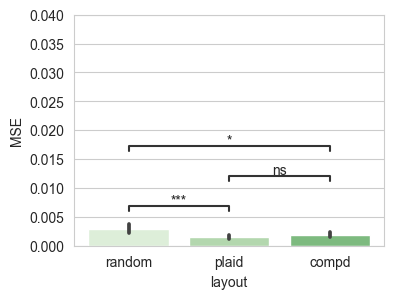

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.166e-03 t=2.668e+00
plaid vs. compd: t-test independent samples, P_val:3.861e-02 t=-2.080e+00
random vs. compd: t-test independent samples, P_val:2.015e-01 t=1.281e+00


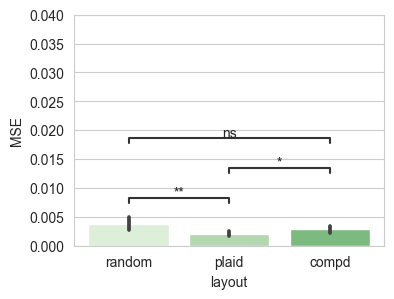

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.024e-04 t=3.528e+00
plaid vs. compd: t-test independent samples, P_val:1.377e-01 t=-1.489e+00
random vs. compd: t-test independent samples, P_val:7.544e-03 t=2.695e+00


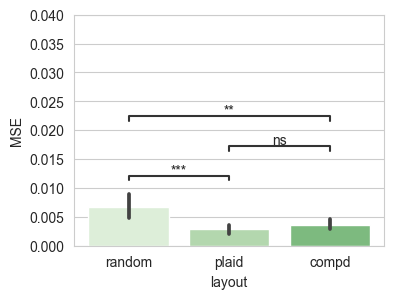

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.836e-05 t=4.373e+00
plaid vs. compd: t-test independent samples, P_val:6.357e-02 t=-1.864e+00
random vs. compd: t-test independent samples, P_val:7.654e-04 t=3.409e+00


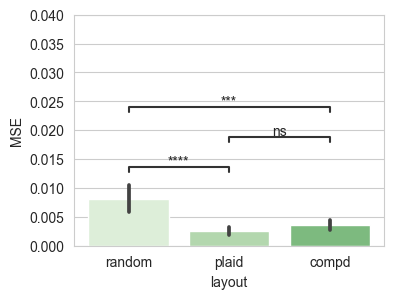

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.842e-04 t=3.337e+00
plaid vs. compd: t-test independent samples, P_val:1.445e-01 t=-1.464e+00
random vs. compd: t-test independent samples, P_val:7.751e-03 t=2.686e+00


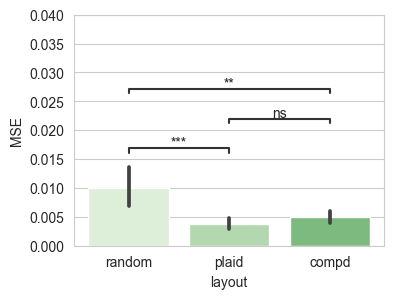

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.787e-05 t=4.379e+00
plaid vs. compd: t-test independent samples, P_val:4.331e-04 t=-3.569e+00
random vs. compd: t-test independent samples, P_val:4.972e-03 t=2.835e+00


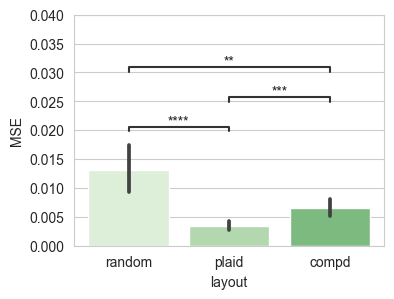

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.793e-04 t=3.689e+00
plaid vs. compd: t-test independent samples, P_val:3.914e-03 t=-2.913e+00
random vs. compd: t-test independent samples, P_val:2.115e-02 t=2.321e+00


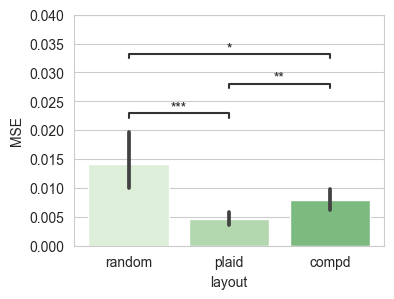

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.924e-05 t=4.089e+00
plaid vs. compd: t-test independent samples, P_val:2.151e-03 t=-3.102e+00
random vs. compd: t-test independent samples, P_val:7.154e-03 t=2.713e+00


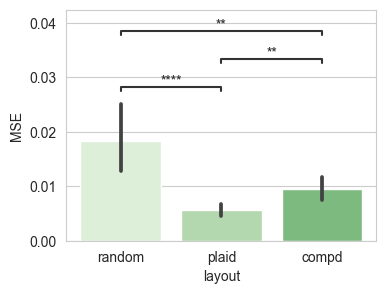

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.380e-04 t=3.875e+00
plaid vs. compd: t-test independent samples, P_val:1.005e-03 t=-3.331e+00
random vs. compd: t-test independent samples, P_val:1.869e-02 t=2.368e+00


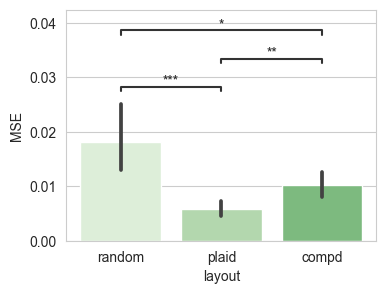

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.201e-04 t=3.752e+00
plaid vs. compd: t-test independent samples, P_val:3.055e-01 t=-1.027e+00
random vs. compd: t-test independent samples, P_val:1.043e-03 t=3.320e+00


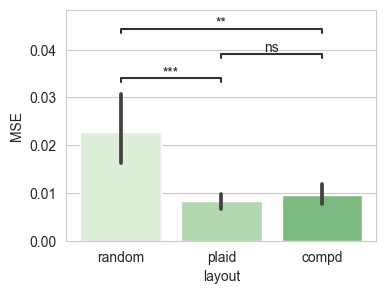

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.185e-05 t=4.331e+00
plaid vs. compd: t-test independent samples, P_val:2.534e-03 t=-3.052e+00
random vs. compd: t-test independent samples, P_val:3.297e-03 t=2.969e+00


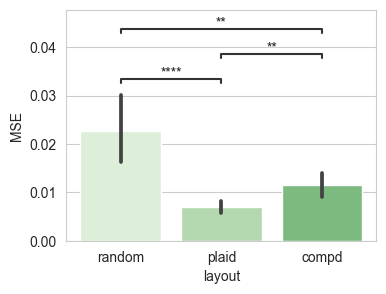

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.043e-04 t=3.666e+00
plaid vs. compd: t-test independent samples, P_val:3.101e-02 t=-2.170e+00
random vs. compd: t-test independent samples, P_val:6.475e-03 t=2.747e+00


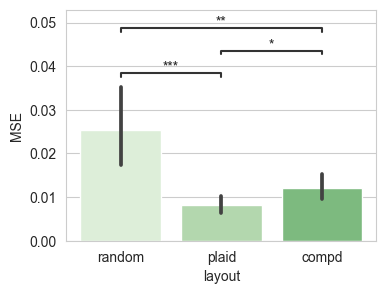

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.036e-04 t=3.948e+00
plaid vs. compd: t-test independent samples, P_val:2.345e-01 t=-1.192e+00
random vs. compd: t-test independent samples, P_val:8.311e-04 t=3.385e+00


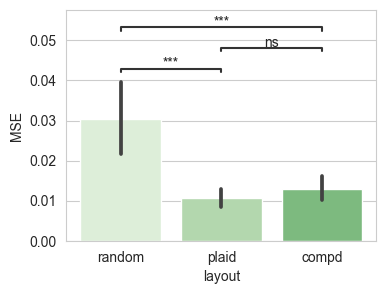

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.171e-05 t=4.478e+00
plaid vs. compd: t-test independent samples, P_val:1.982e-04 t=-3.780e+00
random vs. compd: t-test independent samples, P_val:3.075e-03 t=2.991e+00


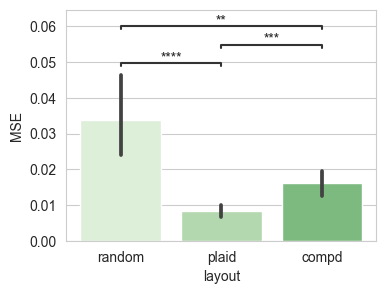

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.137e-04 t=3.925e+00
plaid vs. compd: t-test independent samples, P_val:9.492e-02 t=-1.677e+00
random vs. compd: t-test independent samples, P_val:1.390e-03 t=3.235e+00


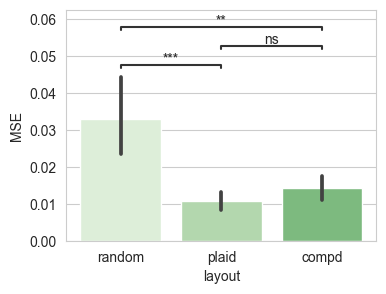

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.885e-05 t=4.265e+00
plaid vs. compd: t-test independent samples, P_val:1.488e-01 t=-1.448e+00
random vs. compd: t-test independent samples, P_val:2.240e-04 t=3.748e+00


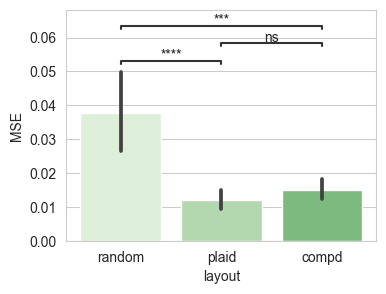

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.739e-05 t=4.385e+00
plaid vs. compd: t-test independent samples, P_val:3.871e-03 t=-2.917e+00
random vs. compd: t-test independent samples, P_val:8.205e-04 t=3.389e+00


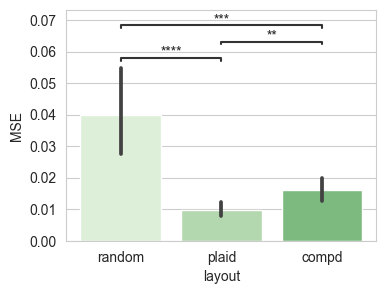

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.855e-04 t=3.683e+00
plaid vs. compd: t-test independent samples, P_val:8.957e-02 t=-1.705e+00
random vs. compd: t-test independent samples, P_val:3.574e-03 t=2.943e+00


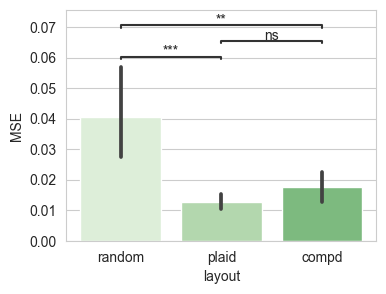

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.011e-04 t=3.955e+00
plaid vs. compd: t-test independent samples, P_val:1.193e-01 t=-1.563e+00
random vs. compd: t-test independent samples, P_val:1.011e-03 t=3.329e+00


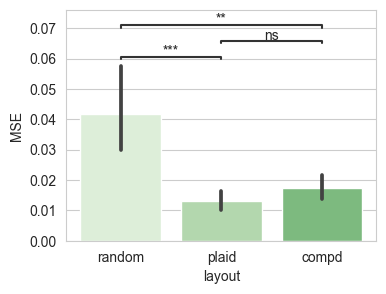

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.300e-05 t=4.117e+00
plaid vs. compd: t-test independent samples, P_val:2.468e-03 t=-3.060e+00
random vs. compd: t-test independent samples, P_val:3.405e-03 t=2.958e+00


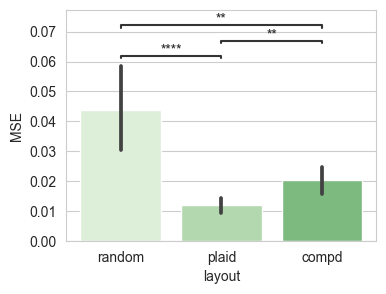

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.694e-04 t=3.822e+00
plaid vs. compd: t-test independent samples, P_val:9.795e-01 t=-2.573e-02
random vs. compd: t-test independent samples, P_val:2.028e-04 t=3.774e+00


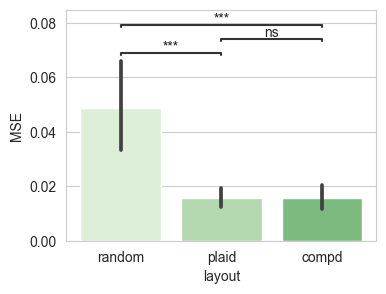

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.265e-05 t=4.118e+00
plaid vs. compd: t-test independent samples, P_val:2.342e-02 t=-2.281e+00
random vs. compd: t-test independent samples, P_val:9.552e-04 t=3.345e+00


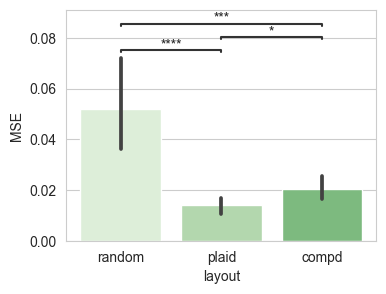

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.005e-04 t=3.777e+00
plaid vs. compd: t-test independent samples, P_val:2.354e-03 t=-3.075e+00
random vs. compd: t-test independent samples, P_val:7.717e-03 t=2.687e+00


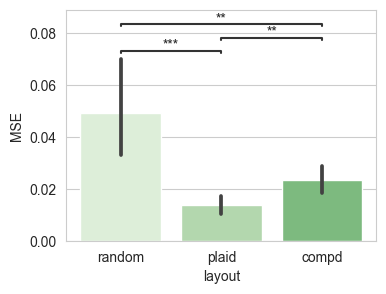

In [34]:
for (neg_controls, pos_controls) in neg_pos_controls_list:
    for error in range(0,26):
        screening_scores_data_filename = 'screening_metrics_data-'+str(neg_controls)+'-'+str(pos_controls)+'-'+str(error/100)+'-20250623-reviewing.csv'
        util.plotting_residual_metrics(data_directory+screening_scores_data_filename,metric='Zfactor', fig_name=screening_scores_data_filename, 
                                       y_max = 0.04, plots_directory = plots_directory,
                                       box_pairs = [   ("random", "plaid"),
                                                       ("random", "compd"),
                                                       ("plaid", "compd")
                                               ],
                                       order = ["random","plaid","compd"])


Finally, we look at the SSMD MSE. Note that we fixed the y_max parameter so that all plots have the same y axis in a suitable way for the supplement.

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.640e-01 t=-4.349e-01
plaid vs. compd: t-test independent samples, P_val:5.360e-01 t=-6.198e-01
random vs. compd: t-test independent samples, P_val:2.641e-01 t=-1.119e+00


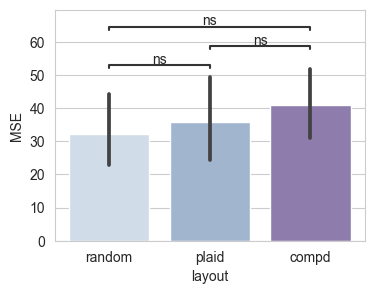

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.190e-01 t=2.291e-01
plaid vs. compd: t-test independent samples, P_val:2.113e-02 t=2.321e+00
random vs. compd: t-test independent samples, P_val:2.401e-03 t=3.068e+00


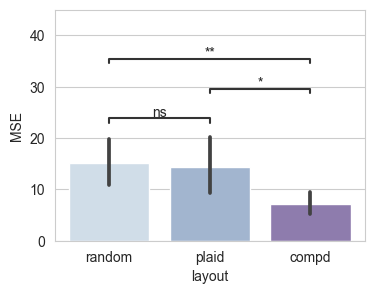

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.823e-03 t=3.153e+00
plaid vs. compd: t-test independent samples, P_val:1.469e-01 t=1.455e+00
random vs. compd: t-test independent samples, P_val:4.522e-05 t=4.156e+00


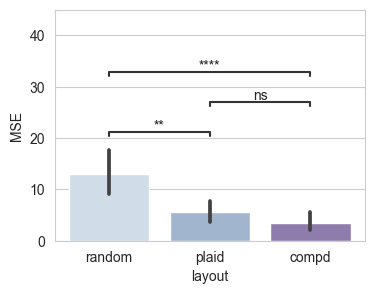

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.738e-02 t=2.220e+00
plaid vs. compd: t-test independent samples, P_val:7.756e-02 t=1.773e+00
random vs. compd: t-test independent samples, P_val:4.176e-05 t=4.175e+00


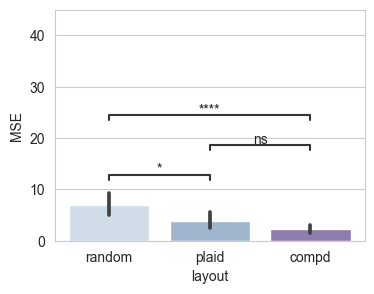

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.258e-02 t=2.295e+00
plaid vs. compd: t-test independent samples, P_val:4.285e-03 t=2.884e+00
random vs. compd: t-test independent samples, P_val:5.070e-07 t=5.165e+00


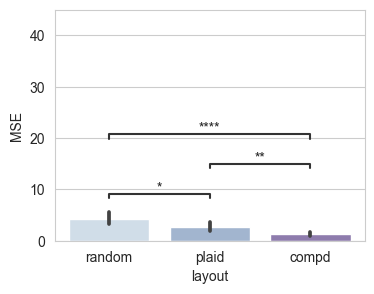

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.393e-03 t=2.959e+00
plaid vs. compd: t-test independent samples, P_val:2.054e-02 t=2.332e+00
random vs. compd: t-test independent samples, P_val:1.079e-05 t=4.497e+00


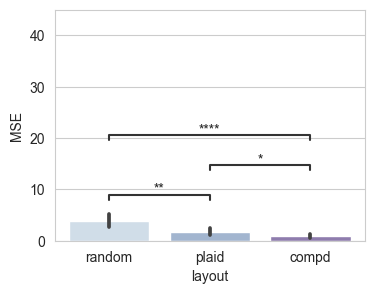

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.705e-04 t=3.820e+00
plaid vs. compd: t-test independent samples, P_val:5.370e-01 t=6.183e-01
random vs. compd: t-test independent samples, P_val:3.647e-04 t=3.616e+00


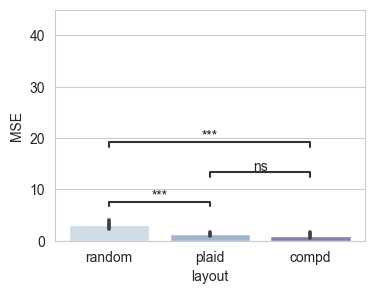

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.955e-02 t=2.070e+00
plaid vs. compd: t-test independent samples, P_val:1.416e-02 t=2.471e+00
random vs. compd: t-test independent samples, P_val:1.773e-04 t=3.809e+00


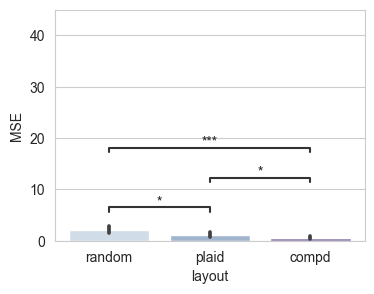

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.195e-03 t=2.626e+00
plaid vs. compd: t-test independent samples, P_val:2.150e-02 t=2.314e+00
random vs. compd: t-test independent samples, P_val:1.512e-06 t=4.934e+00


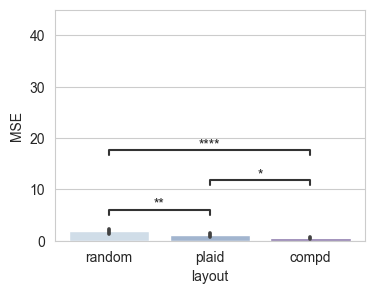

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.904e-02 t=2.196e+00
plaid vs. compd: t-test independent samples, P_val:2.937e-02 t=2.192e+00
random vs. compd: t-test independent samples, P_val:2.912e-05 t=4.263e+00


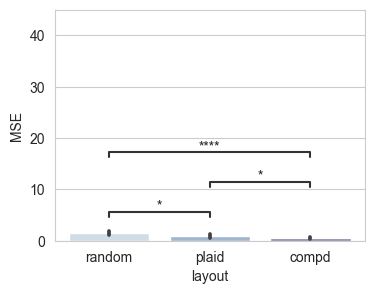

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.196e-02 t=2.158e+00
plaid vs. compd: t-test independent samples, P_val:9.428e-03 t=2.617e+00
random vs. compd: t-test independent samples, P_val:1.924e-06 t=4.882e+00


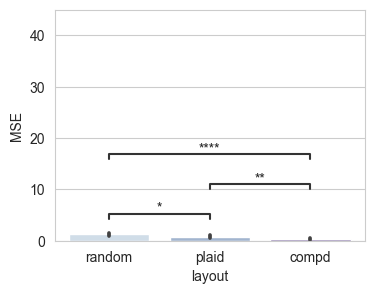

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.348e-02 t=2.139e+00
plaid vs. compd: t-test independent samples, P_val:2.949e-02 t=2.190e+00
random vs. compd: t-test independent samples, P_val:9.590e-06 t=4.524e+00


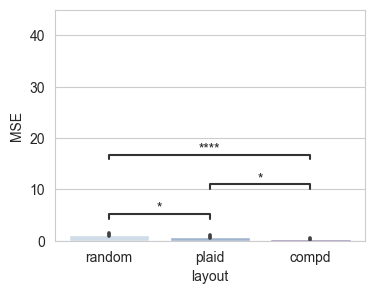

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.262e-03 t=2.624e+00
plaid vs. compd: t-test independent samples, P_val:6.302e-03 t=2.756e+00
random vs. compd: t-test independent samples, P_val:3.379e-08 t=5.708e+00


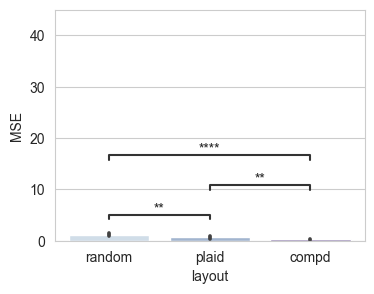

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.499e-02 t=2.450e+00
plaid vs. compd: t-test independent samples, P_val:2.150e-02 t=2.314e+00
random vs. compd: t-test independent samples, P_val:1.643e-05 t=4.399e+00


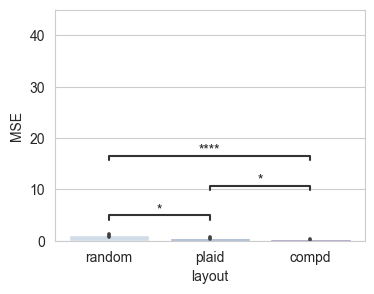

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.343e-03 t=2.754e+00
plaid vs. compd: t-test independent samples, P_val:9.298e-02 t=1.687e+00
random vs. compd: t-test independent samples, P_val:3.155e-05 t=4.243e+00


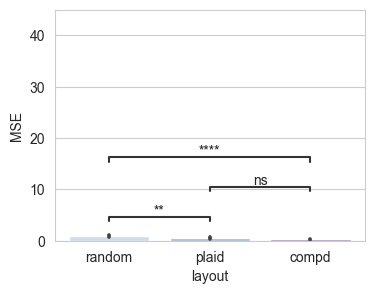

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.372e-02 t=1.796e+00
plaid vs. compd: t-test independent samples, P_val:2.051e-02 t=2.332e+00
random vs. compd: t-test independent samples, P_val:9.389e-06 t=4.529e+00


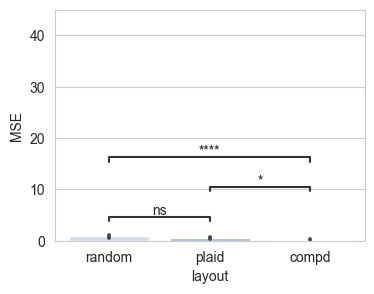

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.092e-03 t=2.827e+00
plaid vs. compd: t-test independent samples, P_val:1.214e-01 t=1.554e+00
random vs. compd: t-test independent samples, P_val:5.322e-05 t=4.116e+00


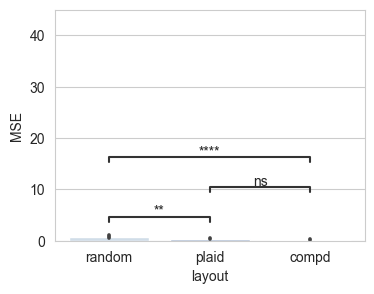

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.366e-03 t=2.620e+00
plaid vs. compd: t-test independent samples, P_val:1.732e-02 t=2.397e+00
random vs. compd: t-test independent samples, P_val:1.194e-06 t=4.985e+00


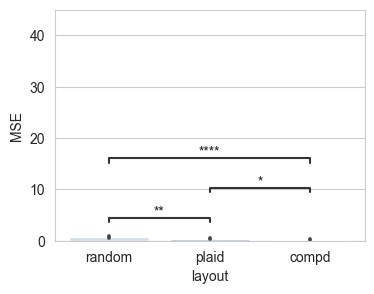

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.298e-02 t=2.289e+00
plaid vs. compd: t-test independent samples, P_val:5.658e-03 t=2.792e+00
random vs. compd: t-test independent samples, P_val:2.383e-06 t=4.836e+00


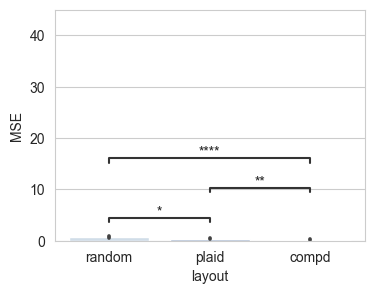

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.494e-02 t=2.121e+00
plaid vs. compd: t-test independent samples, P_val:3.643e-02 t=2.104e+00
random vs. compd: t-test independent samples, P_val:2.300e-05 t=4.319e+00


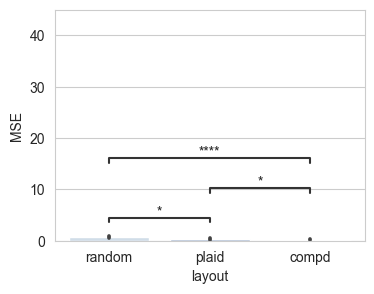

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.838e-03 t=2.782e+00
plaid vs. compd: t-test independent samples, P_val:2.723e-02 t=2.222e+00
random vs. compd: t-test independent samples, P_val:2.704e-06 t=4.808e+00


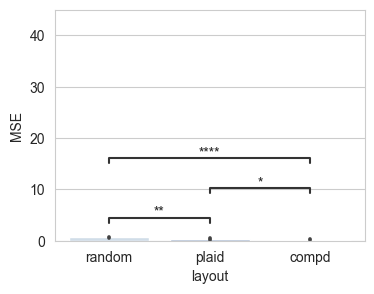

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.221e-02 t=2.525e+00
plaid vs. compd: t-test independent samples, P_val:1.586e-02 t=2.430e+00
random vs. compd: t-test independent samples, P_val:4.656e-06 t=4.688e+00


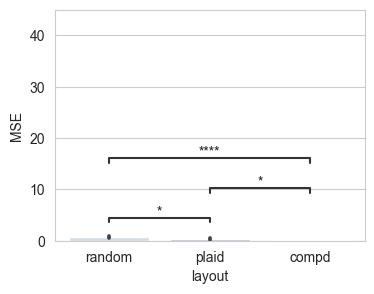

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.804e-02 t=2.210e+00
plaid vs. compd: t-test independent samples, P_val:1.829e-02 t=2.376e+00
random vs. compd: t-test independent samples, P_val:3.317e-05 t=4.231e+00


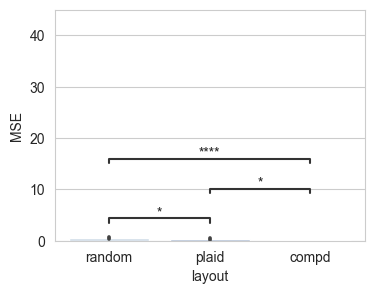

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.897e-02 t=1.979e+00
plaid vs. compd: t-test independent samples, P_val:1.459e-02 t=2.460e+00
random vs. compd: t-test independent samples, P_val:2.691e-05 t=4.282e+00


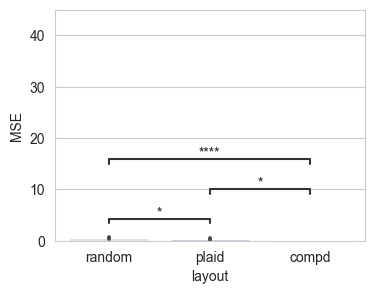

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.389e-02 t=2.134e+00
plaid vs. compd: t-test independent samples, P_val:6.091e-03 t=2.768e+00
random vs. compd: t-test independent samples, P_val:1.886e-06 t=4.887e+00


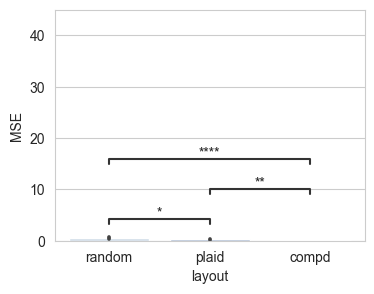

generated-data/quality-assessment-metrics/screening_metrics_data-8-8-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.830e-03 t=2.845e+00
plaid vs. compd: t-test independent samples, P_val:2.030e-02 t=2.336e+00
random vs. compd: t-test independent samples, P_val:1.451e-06 t=4.943e+00


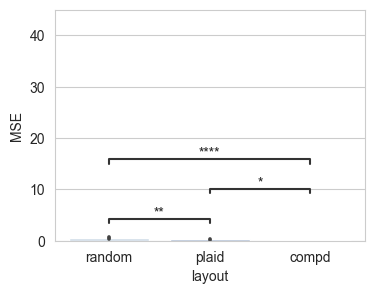

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.162e-01 t=-5.018e-01
plaid vs. compd: t-test independent samples, P_val:3.604e-01 t=-9.164e-01
random vs. compd: t-test independent samples, P_val:2.252e-01 t=-1.216e+00


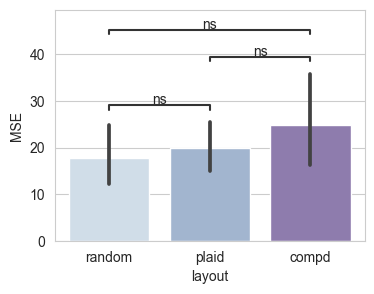

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.641e-01 t=4.505e-02
plaid vs. compd: t-test independent samples, P_val:8.262e-02 t=1.743e+00
random vs. compd: t-test independent samples, P_val:8.656e-03 t=2.647e+00


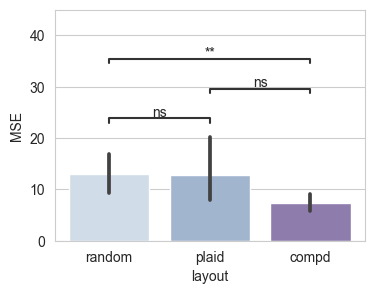

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.049e-01 t=1.271e+00
plaid vs. compd: t-test independent samples, P_val:1.848e-02 t=2.372e+00
random vs. compd: t-test independent samples, P_val:1.001e-03 t=3.331e+00


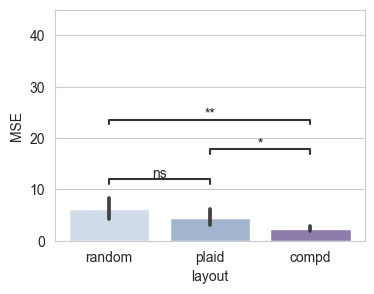

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.112e-02 t=2.168e+00
plaid vs. compd: t-test independent samples, P_val:5.081e-05 t=4.127e+00
random vs. compd: t-test independent samples, P_val:5.409e-04 t=3.507e+00


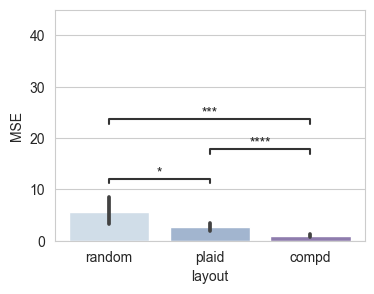

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:7.547e-02 t=1.785e+00
plaid vs. compd: t-test independent samples, P_val:1.113e-02 t=2.558e+00
random vs. compd: t-test independent samples, P_val:4.419e-07 t=5.194e+00


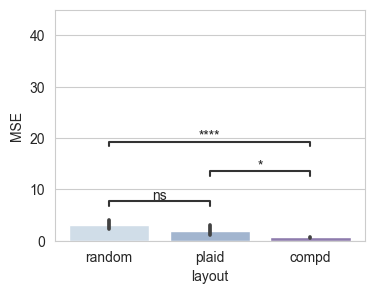

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.019e-02 t=2.338e+00
plaid vs. compd: t-test independent samples, P_val:1.869e-03 t=3.146e+00
random vs. compd: t-test independent samples, P_val:1.252e-05 t=4.462e+00


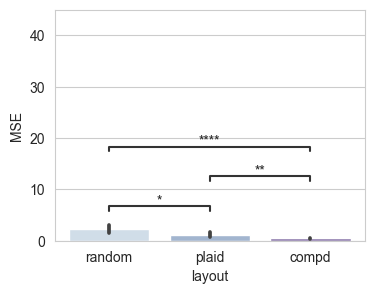

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.571e-02 t=1.849e+00
plaid vs. compd: t-test independent samples, P_val:3.290e-04 t=3.644e+00
random vs. compd: t-test independent samples, P_val:4.485e-06 t=4.696e+00


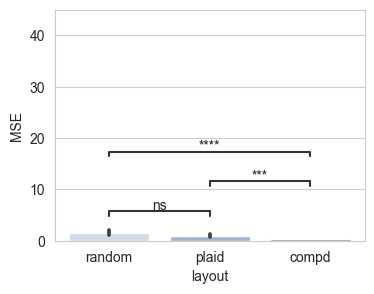

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.643e-01 t=1.395e+00
plaid vs. compd: t-test independent samples, P_val:1.117e-03 t=3.300e+00
random vs. compd: t-test independent samples, P_val:7.761e-05 t=4.022e+00


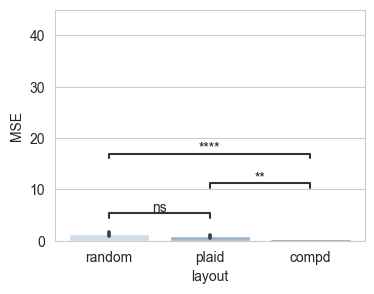

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.899e-02 t=1.979e+00
plaid vs. compd: t-test independent samples, P_val:4.119e-04 t=3.583e+00
random vs. compd: t-test independent samples, P_val:7.095e-05 t=4.044e+00


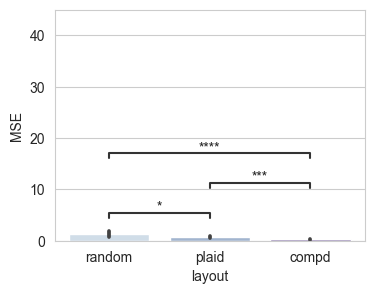

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.141e-02 t=2.165e+00
plaid vs. compd: t-test independent samples, P_val:4.683e-04 t=3.547e+00
random vs. compd: t-test independent samples, P_val:2.001e-05 t=4.352e+00


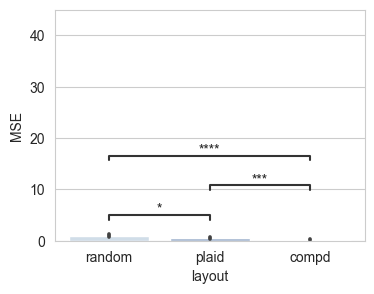

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.558e-02 t=2.247e+00
plaid vs. compd: t-test independent samples, P_val:1.179e-03 t=3.284e+00
random vs. compd: t-test independent samples, P_val:4.018e-05 t=4.185e+00


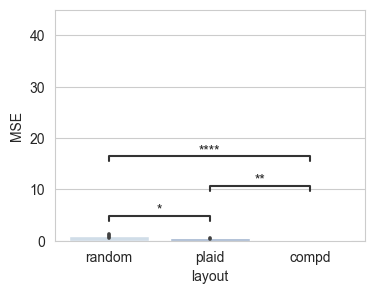

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.501e-02 t=1.854e+00
plaid vs. compd: t-test independent samples, P_val:2.956e-03 t=3.003e+00
random vs. compd: t-test independent samples, P_val:1.067e-04 t=3.941e+00


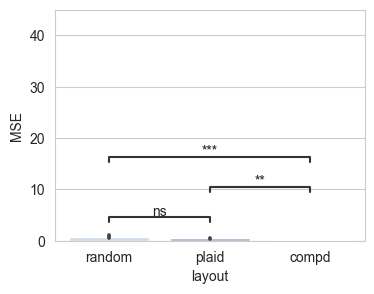

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.385e-02 t=2.480e+00
plaid vs. compd: t-test independent samples, P_val:8.754e-04 t=3.370e+00
random vs. compd: t-test independent samples, P_val:6.042e-05 t=4.084e+00


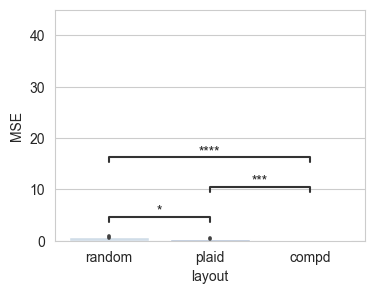

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.989e-02 t=2.066e+00
plaid vs. compd: t-test independent samples, P_val:1.979e-04 t=3.781e+00
random vs. compd: t-test independent samples, P_val:4.794e-06 t=4.681e+00


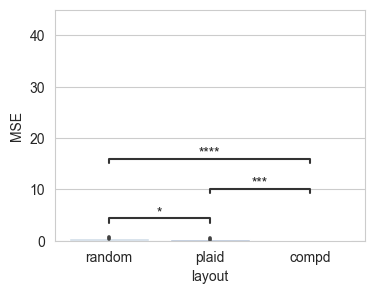

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.012e-02 t=2.064e+00
plaid vs. compd: t-test independent samples, P_val:3.325e-03 t=2.966e+00
random vs. compd: t-test independent samples, P_val:9.766e-06 t=4.520e+00


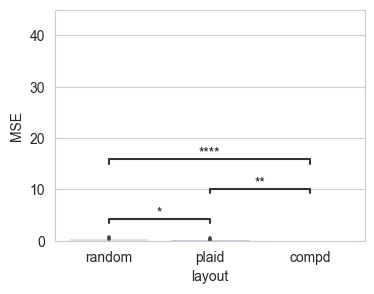

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.608e-02 t=2.424e+00
plaid vs. compd: t-test independent samples, P_val:1.480e-04 t=3.857e+00
random vs. compd: t-test independent samples, P_val:6.536e-06 t=4.611e+00


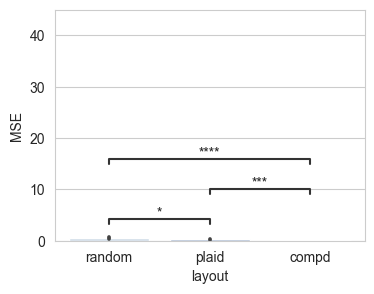

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.625e-02 t=2.236e+00
plaid vs. compd: t-test independent samples, P_val:3.781e-04 t=3.606e+00
random vs. compd: t-test independent samples, P_val:1.299e-07 t=5.443e+00


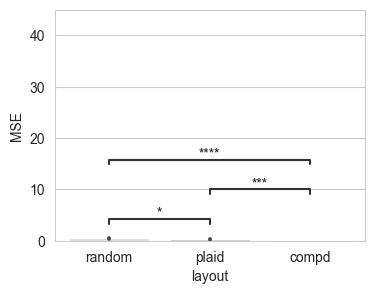

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.380e-02 t=1.736e+00
plaid vs. compd: t-test independent samples, P_val:6.469e-04 t=3.457e+00
random vs. compd: t-test independent samples, P_val:1.555e-05 t=4.412e+00


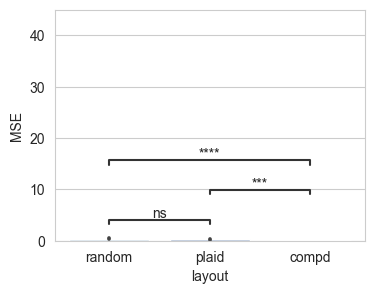

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.072e-01 t=1.617e+00
plaid vs. compd: t-test independent samples, P_val:1.078e-03 t=3.310e+00
random vs. compd: t-test independent samples, P_val:5.676e-06 t=4.643e+00


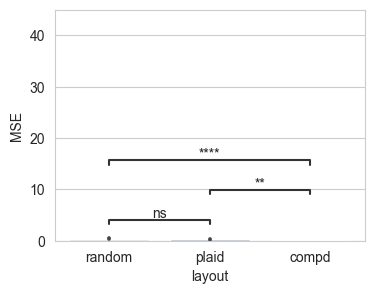

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.759e-02 t=1.908e+00
plaid vs. compd: t-test independent samples, P_val:2.391e-03 t=3.070e+00
random vs. compd: t-test independent samples, P_val:5.016e-06 t=4.671e+00


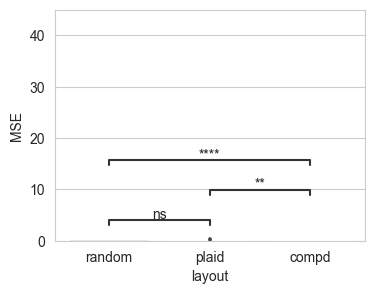

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.899e-02 t=2.362e+00
plaid vs. compd: t-test independent samples, P_val:9.747e-05 t=3.964e+00
random vs. compd: t-test independent samples, P_val:7.852e-06 t=4.570e+00


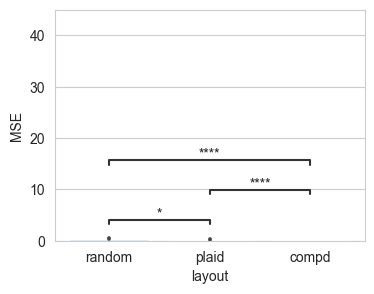

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:3.679e-02 t=2.100e+00
plaid vs. compd: t-test independent samples, P_val:6.643e-04 t=3.449e+00
random vs. compd: t-test independent samples, P_val:3.682e-05 t=4.206e+00


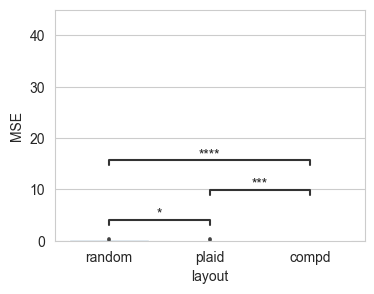

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.919e-02 t=1.896e+00
plaid vs. compd: t-test independent samples, P_val:6.472e-04 t=3.457e+00
random vs. compd: t-test independent samples, P_val:7.573e-06 t=4.578e+00


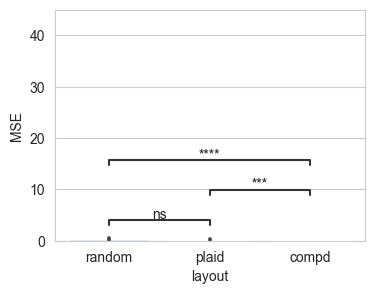

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.396e-02 t=1.682e+00
plaid vs. compd: t-test independent samples, P_val:1.600e-03 t=3.193e+00
random vs. compd: t-test independent samples, P_val:3.524e-06 t=4.750e+00


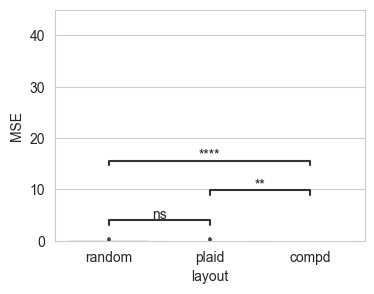

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.468e-03 t=2.804e+00
plaid vs. compd: t-test independent samples, P_val:8.989e-04 t=3.363e+00
random vs. compd: t-test independent samples, P_val:8.186e-07 t=5.065e+00


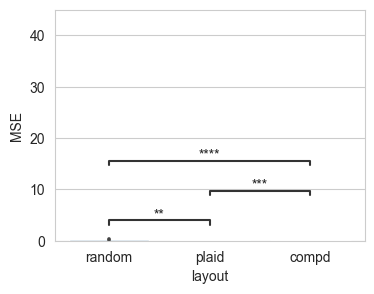

generated-data/quality-assessment-metrics/screening_metrics_data-10-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.540e-02 t=2.249e+00
plaid vs. compd: t-test independent samples, P_val:2.408e-03 t=3.068e+00
random vs. compd: t-test independent samples, P_val:2.517e-05 t=4.298e+00


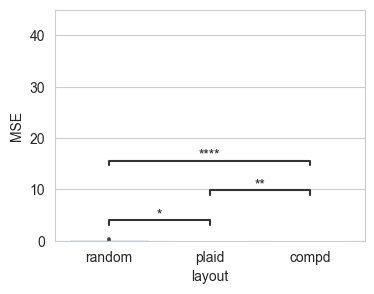

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.0-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.571e-02 t=-1.923e+00
plaid vs. compd: t-test independent samples, P_val:2.430e-02 t=2.267e+00
random vs. compd: t-test independent samples, P_val:7.995e-01 t=2.543e-01


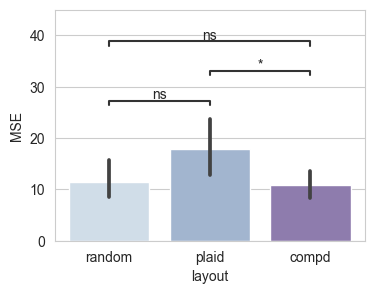

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.01-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.343e-02 t=1.941e+00
plaid vs. compd: t-test independent samples, P_val:5.478e-01 t=6.019e-01
random vs. compd: t-test independent samples, P_val:1.340e-02 t=2.492e+00


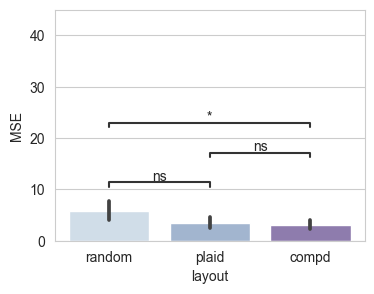

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.02-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.604e-03 t=3.192e+00
plaid vs. compd: t-test independent samples, P_val:8.733e-02 t=-1.717e+00
random vs. compd: t-test independent samples, P_val:6.512e-02 t=1.853e+00


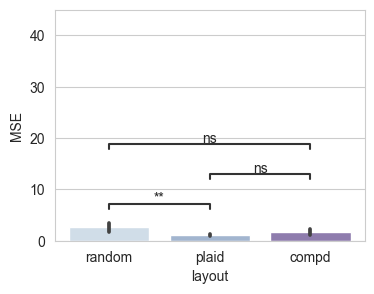

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.03-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.696e-04 t=3.821e+00
plaid vs. compd: t-test independent samples, P_val:3.663e-02 t=-2.102e+00
random vs. compd: t-test independent samples, P_val:3.000e-03 t=2.999e+00


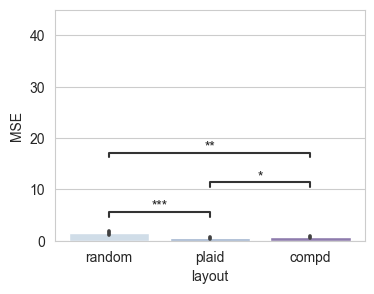

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.04-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.076e-02 t=2.571e+00
plaid vs. compd: t-test independent samples, P_val:4.321e-03 t=-2.881e+00
random vs. compd: t-test independent samples, P_val:4.092e-02 t=2.056e+00


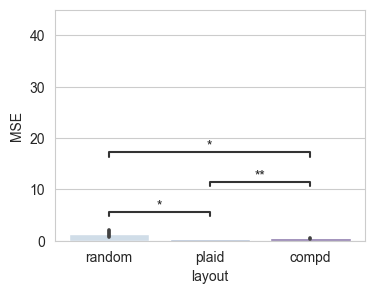

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.05-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.441e-03 t=2.656e+00
plaid vs. compd: t-test independent samples, P_val:6.469e-03 t=-2.747e+00
random vs. compd: t-test independent samples, P_val:2.118e-02 t=2.320e+00


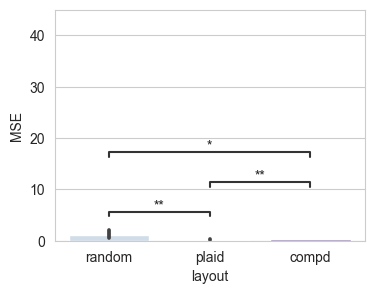

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.06-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:4.160e-03 t=2.894e+00
plaid vs. compd: t-test independent samples, P_val:5.759e-03 t=-2.786e+00
random vs. compd: t-test independent samples, P_val:1.145e-02 t=2.548e+00


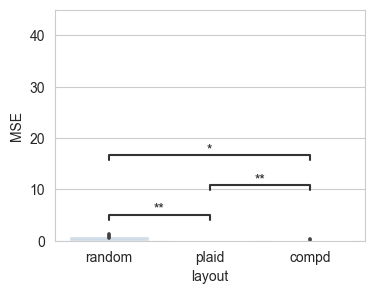

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.07-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.337e-02 t=2.492e+00
plaid vs. compd: t-test independent samples, P_val:3.483e-02 t=-2.123e+00
random vs. compd: t-test independent samples, P_val:2.528e-02 t=2.251e+00


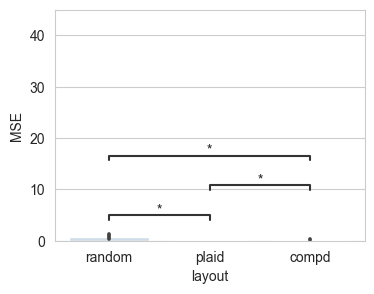

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.08-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.100e-02 t=2.563e+00
plaid vs. compd: t-test independent samples, P_val:1.128e-03 t=-3.297e+00
random vs. compd: t-test independent samples, P_val:3.054e-02 t=2.176e+00


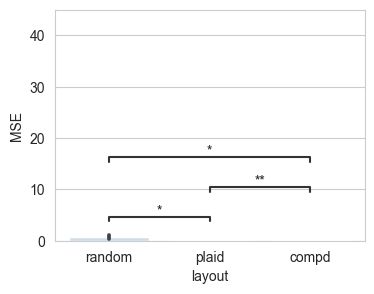

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.09-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.357e-02 t=2.487e+00
plaid vs. compd: t-test independent samples, P_val:3.186e-04 t=-3.653e+00
random vs. compd: t-test independent samples, P_val:3.525e-02 t=2.118e+00


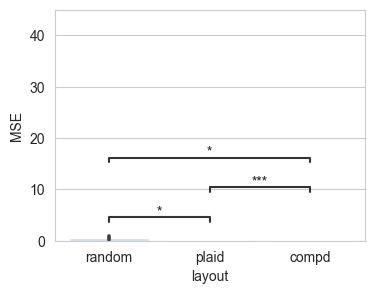

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.1-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:5.772e-03 t=2.786e+00
plaid vs. compd: t-test independent samples, P_val:2.630e-03 t=-3.040e+00
random vs. compd: t-test independent samples, P_val:1.820e-02 t=2.378e+00


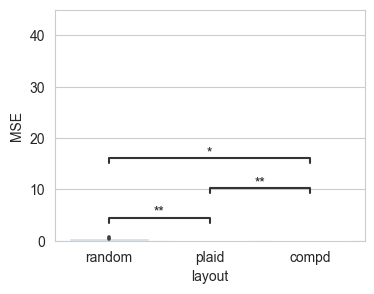

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.11-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.365e-03 t=2.753e+00
plaid vs. compd: t-test independent samples, P_val:7.212e-06 t=-4.589e+00
random vs. compd: t-test independent samples, P_val:2.242e-02 t=2.298e+00


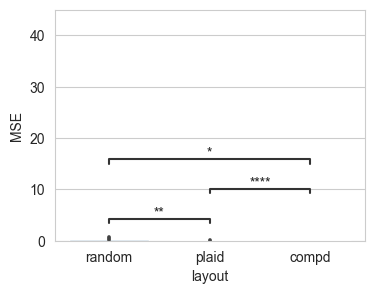

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.12-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:8.636e-03 t=2.648e+00
plaid vs. compd: t-test independent samples, P_val:1.444e-02 t=-2.464e+00
random vs. compd: t-test independent samples, P_val:1.768e-02 t=2.389e+00


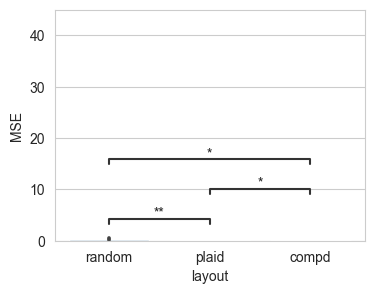

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.13-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.847e-03 t=2.728e+00
plaid vs. compd: t-test independent samples, P_val:1.449e-03 t=-3.222e+00
random vs. compd: t-test independent samples, P_val:2.109e-02 t=2.322e+00


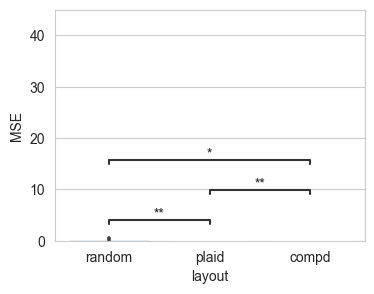

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.14-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.059e-02 t=2.576e+00
plaid vs. compd: t-test independent samples, P_val:2.878e-02 t=-2.200e+00
random vs. compd: t-test independent samples, P_val:2.088e-02 t=2.326e+00


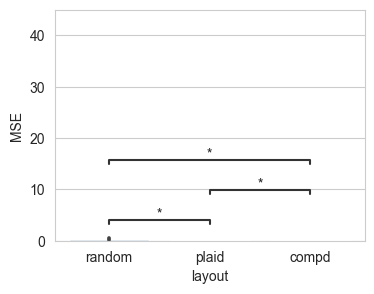

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.15-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.416e-03 t=2.618e+00
plaid vs. compd: t-test independent samples, P_val:4.735e-02 t=-1.993e+00
random vs. compd: t-test independent samples, P_val:1.749e-02 t=2.393e+00


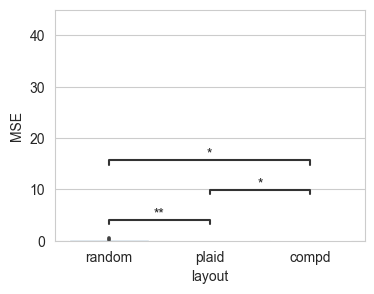

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.16-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:9.915e-03 t=2.600e+00
plaid vs. compd: t-test independent samples, P_val:7.896e-04 t=-3.400e+00
random vs. compd: t-test independent samples, P_val:2.470e-02 t=2.260e+00


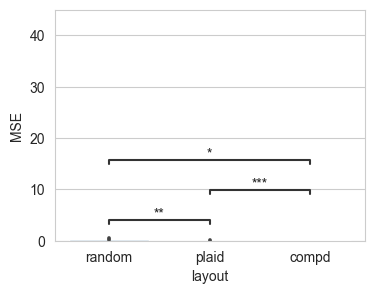

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.17-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.065e-02 t=2.574e+00
plaid vs. compd: t-test independent samples, P_val:4.228e-02 t=-2.042e+00
random vs. compd: t-test independent samples, P_val:1.858e-02 t=2.370e+00


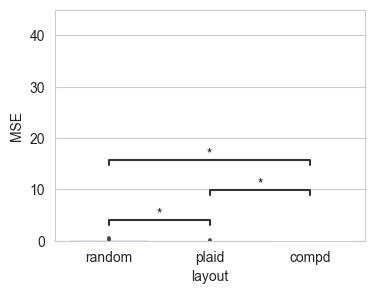

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.18-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:6.602e-03 t=2.740e+00
plaid vs. compd: t-test independent samples, P_val:5.586e-02 t=-1.922e+00
random vs. compd: t-test independent samples, P_val:1.208e-02 t=2.529e+00


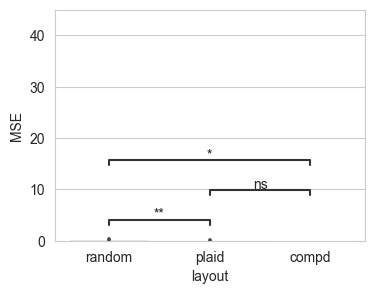

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.19-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.041e-02 t=2.583e+00
plaid vs. compd: t-test independent samples, P_val:3.902e-03 t=-2.914e+00
random vs. compd: t-test independent samples, P_val:2.194e-02 t=2.307e+00


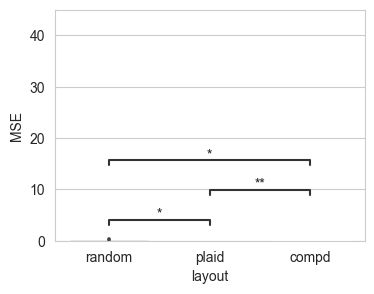

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.2-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.722e-02 t=2.399e+00
plaid vs. compd: t-test independent samples, P_val:1.046e-01 t=-1.629e+00
random vs. compd: t-test independent samples, P_val:2.836e-02 t=2.206e+00


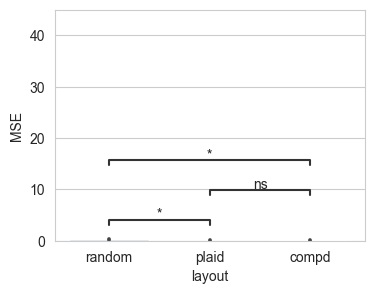

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.21-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.014e-02 t=2.592e+00
plaid vs. compd: t-test independent samples, P_val:7.104e-02 t=-1.813e+00
random vs. compd: t-test independent samples, P_val:1.727e-02 t=2.398e+00


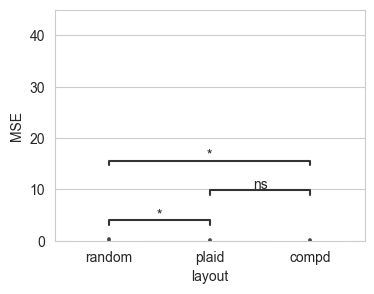

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.22-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.314e-02 t=2.499e+00
plaid vs. compd: t-test independent samples, P_val:1.803e-02 t=-2.381e+00
random vs. compd: t-test independent samples, P_val:2.450e-02 t=2.264e+00


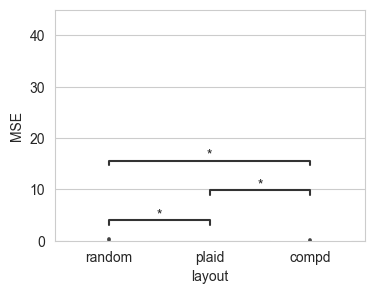

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.23-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.058e-02 t=2.577e+00
plaid vs. compd: t-test independent samples, P_val:4.980e-01 t=-6.787e-01
random vs. compd: t-test independent samples, P_val:1.296e-02 t=2.504e+00


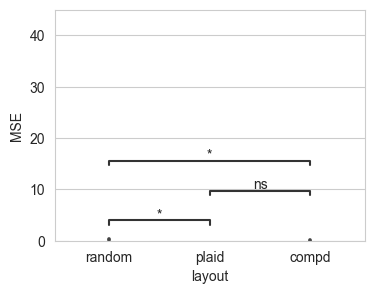

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.24-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:1.288e-02 t=2.506e+00
plaid vs. compd: t-test independent samples, P_val:6.321e-02 t=-1.866e+00
random vs. compd: t-test independent samples, P_val:2.108e-02 t=2.322e+00


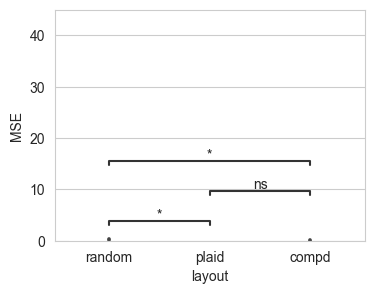

generated-data/quality-assessment-metrics/screening_metrics_data-20-10-0.25-20250623-reviewing.csv
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

random vs. plaid: t-test independent samples, P_val:2.157e-02 t=2.313e+00
plaid vs. compd: t-test independent samples, P_val:1.264e-03 t=-3.263e+00
random vs. compd: t-test independent samples, P_val:4.609e-02 t=2.005e+00


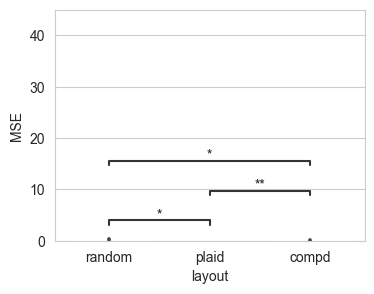

In [36]:
for (neg_controls, pos_controls) in neg_pos_controls_list:
    for error in range(0,26):
        screening_scores_data_filename = 'screening_metrics_data-'+str(neg_controls)+'-'+str(pos_controls)+'-'+str(error/100)+'-20250623-reviewing.csv'
        util.plotting_residual_metrics(data_directory+screening_scores_data_filename,metric='SSMD', fig_name=screening_scores_data_filename, 
                                       y_max = 45, palette = sns.color_palette("BuPu",4), plots_directory = plots_directory,
                                       box_pairs = [   ("random", "plaid"),
                                                       ("random", "compd"),
                                                       ("plaid", "compd")
                                               ],
                                       order = ["random","plaid","compd"])
    

## Examples of how to test other types of errors and plate effects

In [18]:
# Other options
#error_types = [{'type':"right-half", 'error_function':dt.add_errors_to_right_columns_half}]
#error_types = [{'type':"diagonal", 'error_function':dt.add_diagonal_errors}]
               #{'type':"left", 'error_function':dt.add_linear_errors_to_left_columns},
               #{'type':"right", 'error_function':dt.add_linear_errors_to_right_columns},
               #{'type':"top", 'error_function':dt.add_linear_errors_to_upper_rows},
               #{'type':"bottom", 'error_function':dt.add_linear_errors_to_lower_rows},
               #{'type':"left-exp", 'error_function':dt.add_exponential_errors_to_left_columns},
               #{'type':"top-exp", 'error_function':dt.add_exponential_errors_to_upper_rows},
               #{'type':"upper-half", 'error_function':dt.add_linear_errors_to_upper_rows_half},
               #{'type':"lower-half", 'error_function':dt.add_linear_errors_to_lower_rows_half},
               #{'type':"right-half", 'error_function':dt.add_linear_errors_to_right_columns_half}]


## References

[1] Zhang, X.D., 2008. Novel analytic criteria and effective plate designs for quality control in genome-scale RNAi screens. _Journal of biomolecular screening_, 13(5), pp.363-377.